## 📦 Import Required Libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.svm import NuSVC
from sklearn.metrics import (
    precision_score, 
    recall_score, 
    f1_score, 
    roc_auc_score, 
    roc_curve, 
    ConfusionMatrixDisplay,
    classification_report
)
from sklearn.calibration import calibration_curve
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_val_score
from imblearn.over_sampling import BorderlineSMOTE
from sklearn.calibration import CalibratedClassifierCV
from imblearn.over_sampling import ADASYN
from imblearn.under_sampling import TomekLinks
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.utils import resample
from imblearn.combine import SMOTEENN
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler, QuantileTransformer
from sklearn.model_selection import GridSearchCV
from sklearn.utils.class_weight import compute_sample_weight

## 💻 adjusting display settings

In [3]:
pd.options.display.max_columns = 100

## 📊 Load Framingham Dataset

In [4]:
df = pd.read_csv('framingham.csv')
df

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4235,0,48,2.0,1,20.0,NaN,0,0,0,248.0,131.0,72.0,22.00,84.0,86.0,0
4236,0,44,1.0,1,15.0,0.0,0,0,0,210.0,126.5,87.0,19.16,86.0,NaN,0
4237,0,52,2.0,0,0.0,0.0,0,0,0,269.0,133.5,83.0,21.47,80.0,107.0,0
4238,1,40,3.0,0,0.0,0.0,0,1,0,185.0,141.0,98.0,25.60,67.0,72.0,0


## ℹ️ Display DataFrame Information

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4240 entries, 0 to 4239
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   male             4240 non-null   int64  
 1   age              4240 non-null   int64  
 2   education        4135 non-null   float64
 3   currentSmoker    4240 non-null   int64  
 4   cigsPerDay       4211 non-null   float64
 5   BPMeds           4187 non-null   float64
 6   prevalentStroke  4240 non-null   int64  
 7   prevalentHyp     4240 non-null   int64  
 8   diabetes         4240 non-null   int64  
 9   totChol          4190 non-null   float64
 10  sysBP            4240 non-null   float64
 11  diaBP            4240 non-null   float64
 12  BMI              4221 non-null   float64
 13  heartRate        4239 non-null   float64
 14  glucose          3852 non-null   float64
 15  TenYearCHD       4240 non-null   int64  
dtypes: float64(9), int64(7)
memory usage: 530.1 KB


## 🔍 Check for Missing Values

In [6]:
df.isnull().sum()

male                 0
age                  0
education          105
currentSmoker        0
cigsPerDay          29
BPMeds              53
prevalentStroke      0
prevalentHyp         0
diabetes             0
totChol             50
sysBP                0
diaBP                0
BMI                 19
heartRate            1
glucose            388
TenYearCHD           0
dtype: int64

## Handle missing Values

### Smoking Fill cigsPerDay

In [7]:
#If currentSmoker is 0, cigsPerDay should be 0.
df.loc[(df['currentSmoker'] == 0) & (df['cigsPerDay'].isna()), 'cigsPerDay'] = 0

# For remaining NaNs (where currentSmoker is 1), use the median of smokers
smoker_median = df[df['currentSmoker'] == 1]['cigsPerDay'].median()
df['cigsPerDay'] = df['cigsPerDay'].fillna(smoker_median)

### glucose

In [8]:
# Fill glucose based on diabetes status 
df['glucose'] = df.groupby('diabetes')['glucose'].transform(lambda x: x.fillna(x.median()))

### BPMeds

In [9]:
df['BPMeds'] = df['BPMeds'].fillna(df['BPMeds'].mode()[0])

### totChol, BMI, hearte rate

In [10]:
for col in ['totChol', 'BMI','heartRate']:
    df[col] = df[col].fillna(df[col].median())

In [11]:
df.isnull().sum()

male                 0
age                  0
education          105
currentSmoker        0
cigsPerDay           0
BPMeds               0
prevalentStroke      0
prevalentHyp         0
diabetes             0
totChol              0
sysBP                0
diaBP                0
BMI                  0
heartRate            0
glucose              0
TenYearCHD           0
dtype: int64

## Recalculating the Risk Score

In [12]:
def get_risk_mapping(points, is_male):
    """Official 2008 Point-to-Risk Percentage Mapping."""
    if points < 0: return 1.0
    if is_male:
        mapping = {
            -2: 1.1, -1: 1.4, 0: 1.6, 1: 1.9, 2: 2.3, 3: 2.8, 4: 3.3, 
            5: 3.9, 6: 4.7, 7: 5.6, 8: 6.7, 9: 7.9, 10: 9.4, 11: 11.2, 
            12: 13.2, 13: 15.6, 14: 18.4, 15: 21.6, 16: 25.3, 17: 29.4
        }
        return mapping.get(points, 30.0 if points >= 18 else 1.0)
    else:
        mapping = {
            -2: 1.0, -1: 1.0, 0: 1.2, 1: 1.5, 2: 1.7, 3: 2.0, 4: 2.4, 
            5: 2.8, 6: 3.3, 7: 3.9, 8: 4.5, 9: 5.3, 10: 6.3, 11: 7.3, 
            12: 8.6, 13: 10.0, 14: 11.7, 15: 13.7, 16: 15.9, 17: 18.5,
            18: 21.5, 19: 24.8, 20: 28.5
        }
        return mapping.get(points, 21.5 if points >= 18 else 1.2)

def calculate_frs_plus(row, race='white'):
    # Inputs from CSV
    age, male, sbp, bmi, chol = row['age'], row['male']==1, row['sysBP'], row['BMI'], row['totChol']
    treated, smoker, diabetes = row['BPMeds']==1, row['currentSmoker']==1, row['diabetes']==1
    
    p = 0
    # 1. Age Points
    if male:
        age_pts = {35:0, 40:2, 45:5, 50:7, 55:8, 60:10, 65:11, 70:12, 75:14}
        p += next((v for k, v in age_pts.items() if age < k), 15)
    else:
        age_pts = {35:0, 40:2, 45:4, 50:5, 55:7, 60:8, 65:9, 70:10, 75:11}
        p += next((v for k, v in age_pts.items() if age < k), 12)

    # 2. Cholesterol (mg/dL) - HDL Removed
    if chol < 160: p += 0
    elif chol < 200: p += 1
    elif chol < 240: p += (2 if male else 3)
    elif chol < 280: p += (3 if male else 4)
    else: p += (4 if male else 5)

    # 3. Systolic BP (Treated vs Untreated)
    if male:
        if treated:
            p += next((v for k, v in {120:0, 130:2, 140:3, 160:4}.items() if sbp < k), 5)
        else:
            p += next((v for k, v in {120:-2, 130:0, 140:1, 160:2}.items() if sbp < k), 3)
    else:
        if treated:
            p += next((v for k, v in {120:-1, 130:2, 140:3, 150:5, 160:6}.items() if sbp < k), 7)
        else:
            p += next((v for k, v in {120:-3, 130:0, 140:1, 150:2, 160:4}.items() if sbp < k), 5)

    # 4. Lifestyle & BMI Modification
    p += (4 if male else 3) if smoker else 0
    p += (3 if male else 4) if diabetes else 0
    #p += (2 if bmi >= 30 else 1 if bmi >= 25 else 0)

    # 5. Base Risk Calculation
    risk = get_risk_mapping(p, male)
    
    # 6. Age-Adaptive Race Penalty (Adaptive Multiplier)
    if race == 'black':
        # Starts at 1.25 at age 40, slides to 1.10 at 75
        mult = max(1.10, 1.25 - ((age - 40) * 0.0043)) if age > 40 else 1.25
        risk *= mult
        
    return round(risk, 2)

# Load and Process
try:
    df['CVD Risk Score'] = df.apply(lambda x: calculate_frs_plus(x, 'white'), axis=1)

    print("--- Framingham+ Calculation Complete ---")
    print(df[['age', 'male', 'sysBP', 'totChol', 'BMI', 'CVD Risk Score', 'FRS_Plus_Black']].head(10))
    
    # Summary of the 'Aggressiveness'
    print(f"\nAverage Risk (White): {df['CVD Risk Score'].mean():.2f}%")
    print(f"Average Risk (Black): {df['FRS_Plus_Black'].mean():.2f}%")

except FileNotFoundError:
    print("Error: framingham.csv not found.")
except Exception as e:
    print(f"An error occurred: {e}")

#df.to_csv('Framingham Regression Dataset.csv', index= False)
    

--- Framingham+ Calculation Complete ---
An error occurred: "['FRS_Plus_Black'] not in index"


In [13]:
sick = df[df['TenYearCHD'] == 1]
bins = [0, 5, 10, 20, 100]
labels = ['5%','<10%', '10-20%', '>20%']
counts = pd.cut(sick['CVD Risk Score'], bins=bins, labels=labels).value_counts().sort_index()

print("--- CVD Events by Risk Tier ---")
for tier, count in counts.items():
    print(f"{tier}: {count} ({count/len(sick)*100:.1f}%)")

--- CVD Events by Risk Tier ---
5%: 45 (7.0%)
<10%: 122 (18.9%)
10-20%: 211 (32.8%)
>20%: 266 (41.3%)


In [14]:
df

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD,CVD Risk Score
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0,1.9
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0,5.3
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0,18.4
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1,24.8
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0,11.7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4235,0,48,2.0,1,20.0,0.0,0,0,0,248.0,131.0,72.0,22.00,84.0,86.0,0,10.0
4236,0,44,1.0,1,15.0,0.0,0,0,0,210.0,126.5,87.0,19.16,86.0,78.0,0,6.3
4237,0,52,2.0,0,0.0,0.0,0,0,0,269.0,133.5,83.0,21.47,80.0,107.0,0,8.6
4238,1,40,3.0,0,0.0,0.0,0,1,0,185.0,141.0,98.0,25.60,67.0,72.0,0,6.7


In [15]:
# Cat OR Quant :
x=df
cat = []
quant = []
for col in x.columns:
  if df[col].dtype == 'object':
    cat.append(col)
  else:
    quant.append(col)

## 🗑 Remove Duplicate Rows if exist

In [16]:
df = df.drop_duplicates()

## EDA


**Goal:** The primary goal of EDA is to understand the dataset before we begin any formal modeling. It's a critical first step for:

* Spotting errors and outliers.
* Understanding the structure and data types of our features.
* Analyzing the distribution of key variables (using plots like **histograms** and **box plots**).
* Identifying patterns and relationships between variables (using **scatter plots** and correlation heatmaps).
* Forming initial hypotheses that will guide our feature engineering and model selection.

### 🎨 Styling our charts

In [17]:
plt.style.use('dark_background')

custom_palette = {
    "High (>20%)": "#FF002B",  # A strong, bright "metallic" red
    "Moderate (10-20%)": "#633535",    # A dark, neutral grey
    "Low (5-10%)":"#CC9999" ,# A dark, neutral grey
    "Very Low (≤5%)": "#59AD75"
}

colors_list = [ "#FBFF00B3","#536335","#FF0000","#19DA0F"]

## Categorize the risk level

In [18]:
def categorize_risk(score):
    if score <= 5: return 'Very Low (≤5%)'
    if score <= 10: return 'Low (5-10%)'
    if score <= 20: return 'Moderate (10-20%)'
    return 'High (>20%)'

# Apply categorization
df['CVD Risk Level'] = df['CVD Risk Score'].apply(categorize_risk)
order = ['Very Low (≤5%)', 'Low (5-10%)', 'Moderate (10-20%)', 'High (>20%)']

In [19]:
df

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD,CVD Risk Score,CVD Risk Level
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0,1.9,Very Low (≤5%)
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0,5.3,Low (5-10%)
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0,18.4,Moderate (10-20%)
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1,24.8,High (>20%)
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0,11.7,Moderate (10-20%)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4235,0,48,2.0,1,20.0,0.0,0,0,0,248.0,131.0,72.0,22.00,84.0,86.0,0,10.0,Low (5-10%)
4236,0,44,1.0,1,15.0,0.0,0,0,0,210.0,126.5,87.0,19.16,86.0,78.0,0,6.3,Low (5-10%)
4237,0,52,2.0,0,0.0,0.0,0,0,0,269.0,133.5,83.0,21.47,80.0,107.0,0,8.6,Low (5-10%)
4238,1,40,3.0,0,0.0,0.0,0,1,0,185.0,141.0,98.0,25.60,67.0,72.0,0,6.7,Low (5-10%)


In [20]:
df['CVD Risk Level'].value_counts()

CVD Risk Level
Low (5-10%)          1244
Moderate (10-20%)    1127
Very Low (≤5%)        993
High (>20%)           876
Name: count, dtype: int64

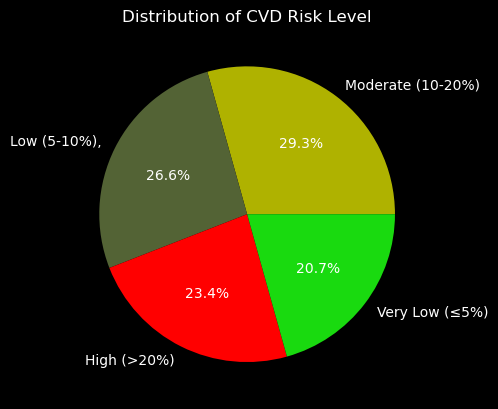

In [21]:
plt.pie(df['CVD Risk Level'].value_counts().values, labels= ['Moderate (10-20%)', 'Low (5-10%),','High (>20%)','Very Low (≤5%)'], autopct='%1.1f%%', colors = colors_list)
plt.title('Distribution of CVD Risk Level')
plt.show()

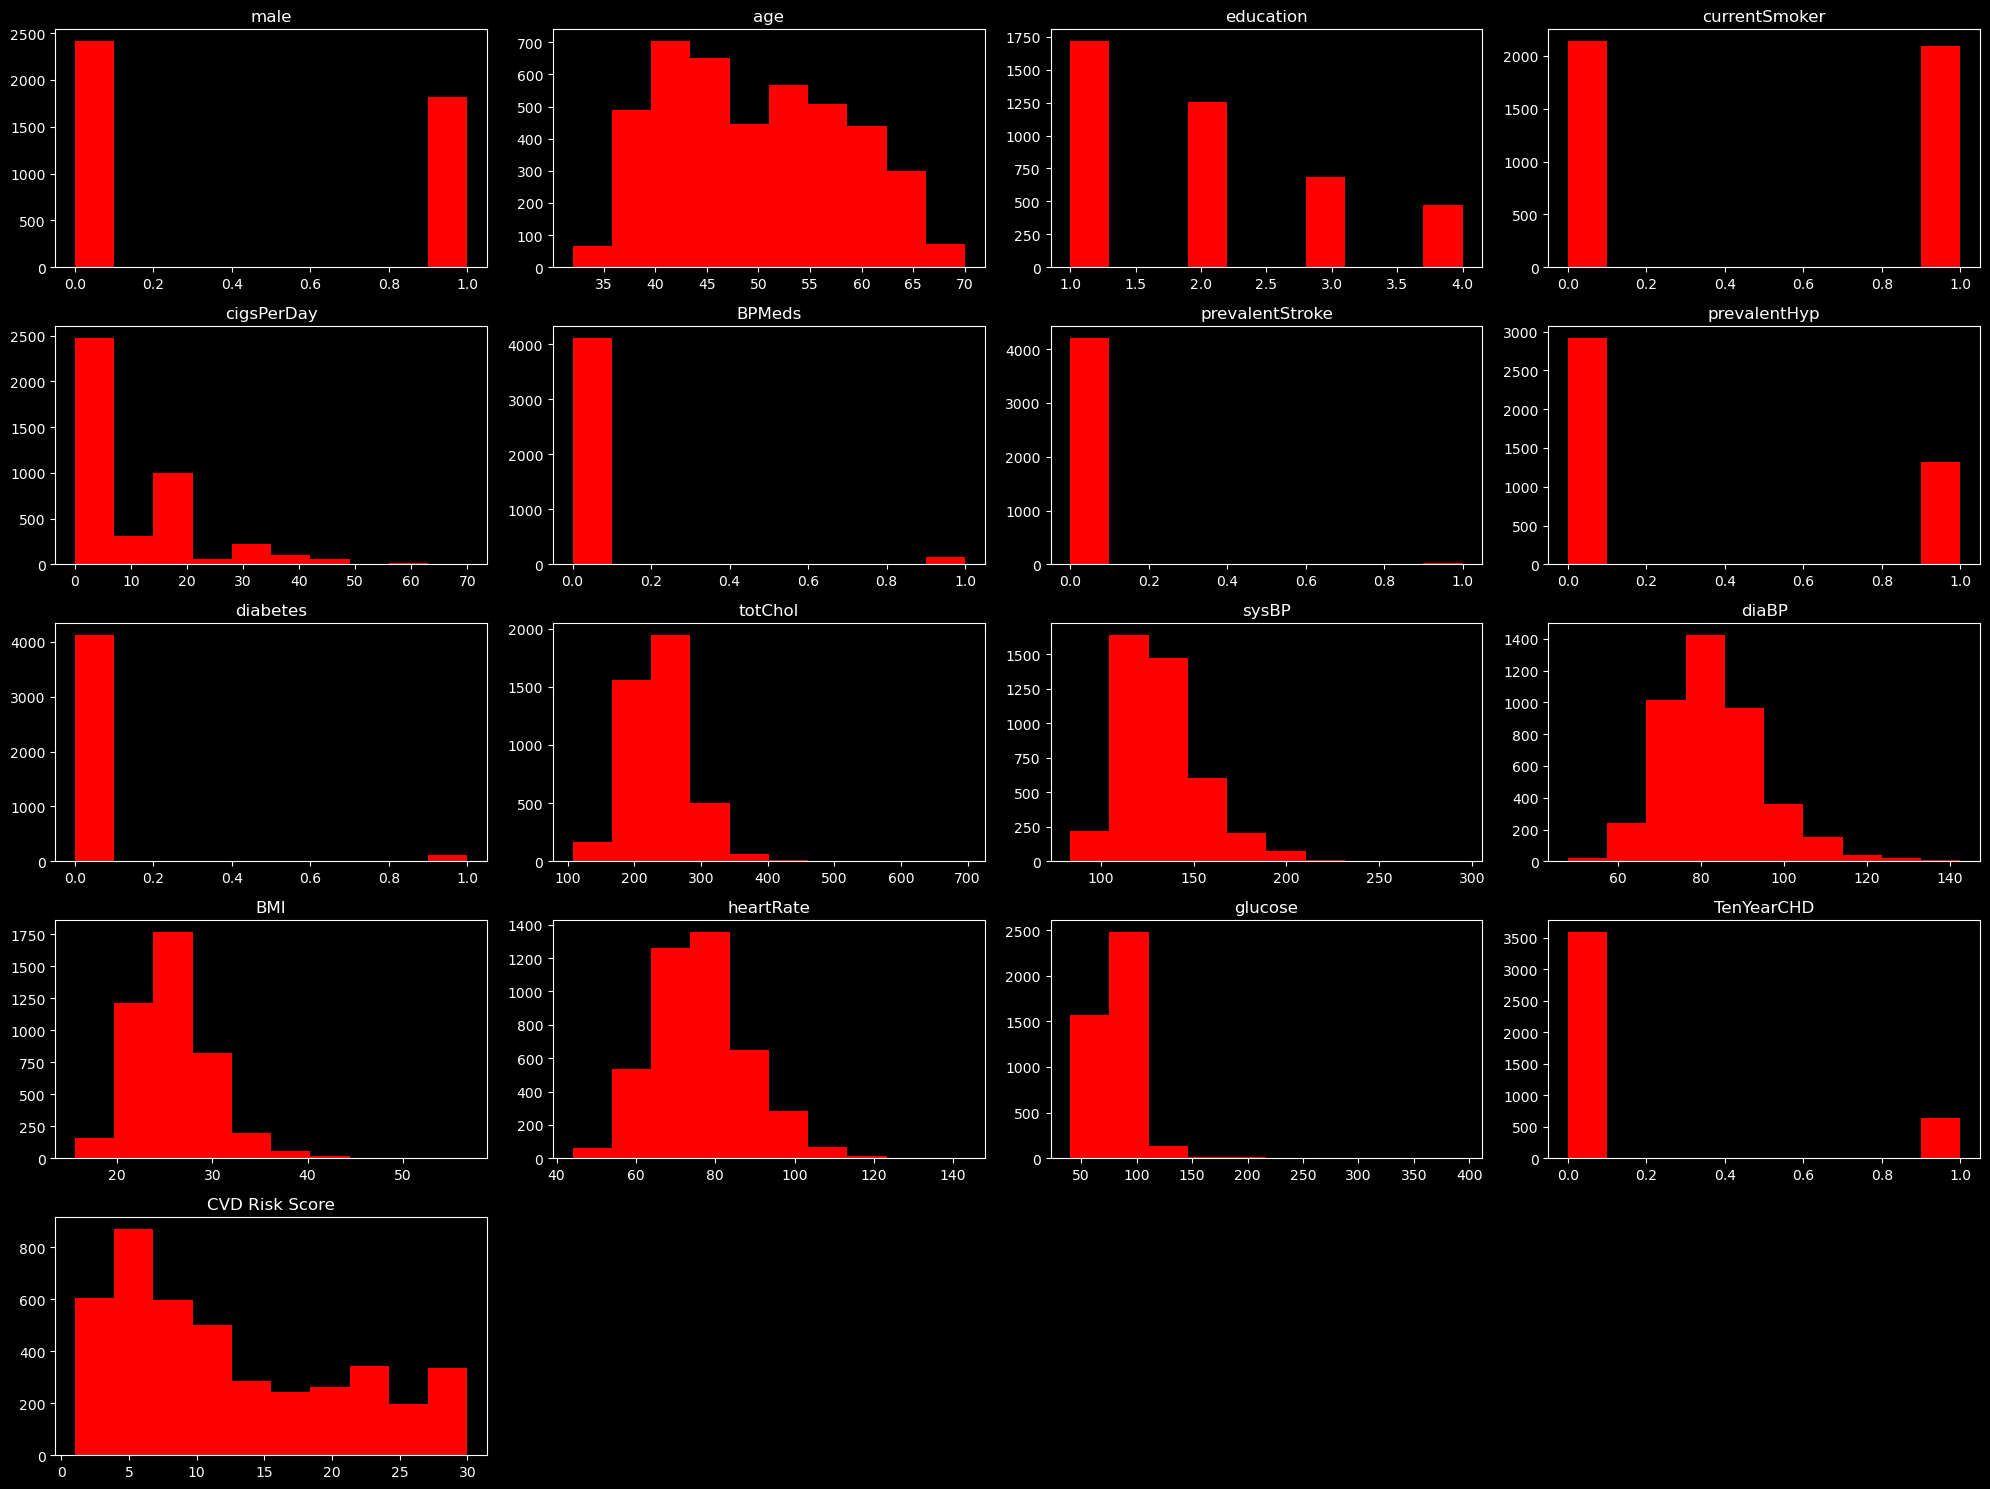

In [22]:
df.hist(figsize=(20,15), color = 'red', grid=0)
plt.tight_layout()

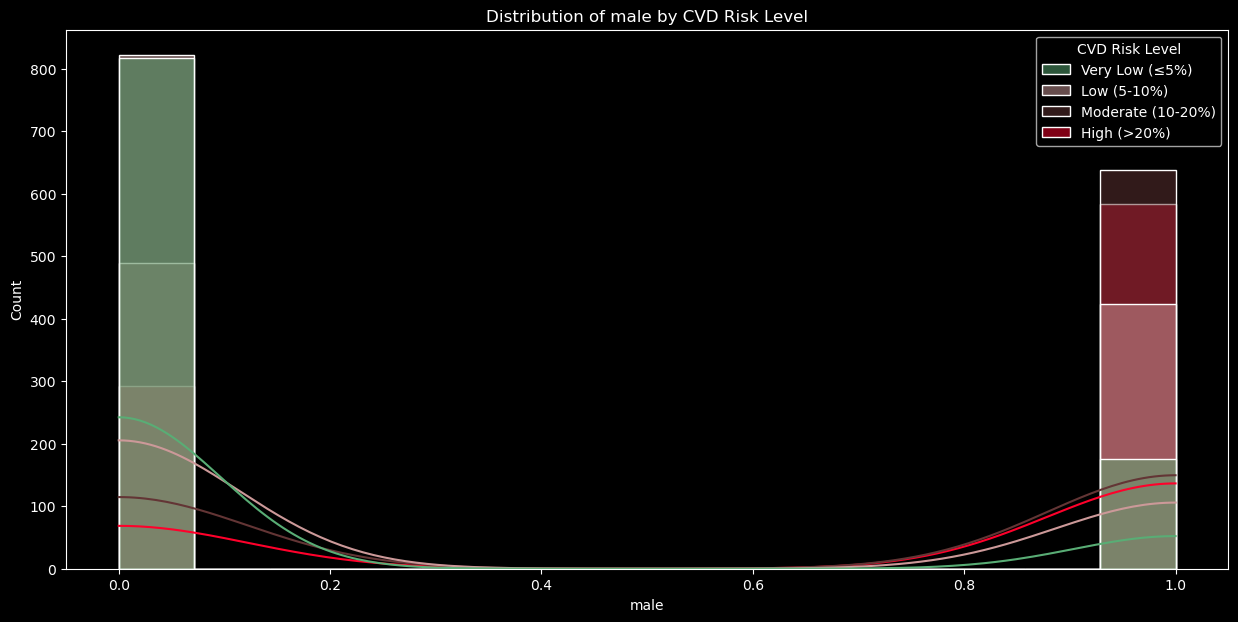

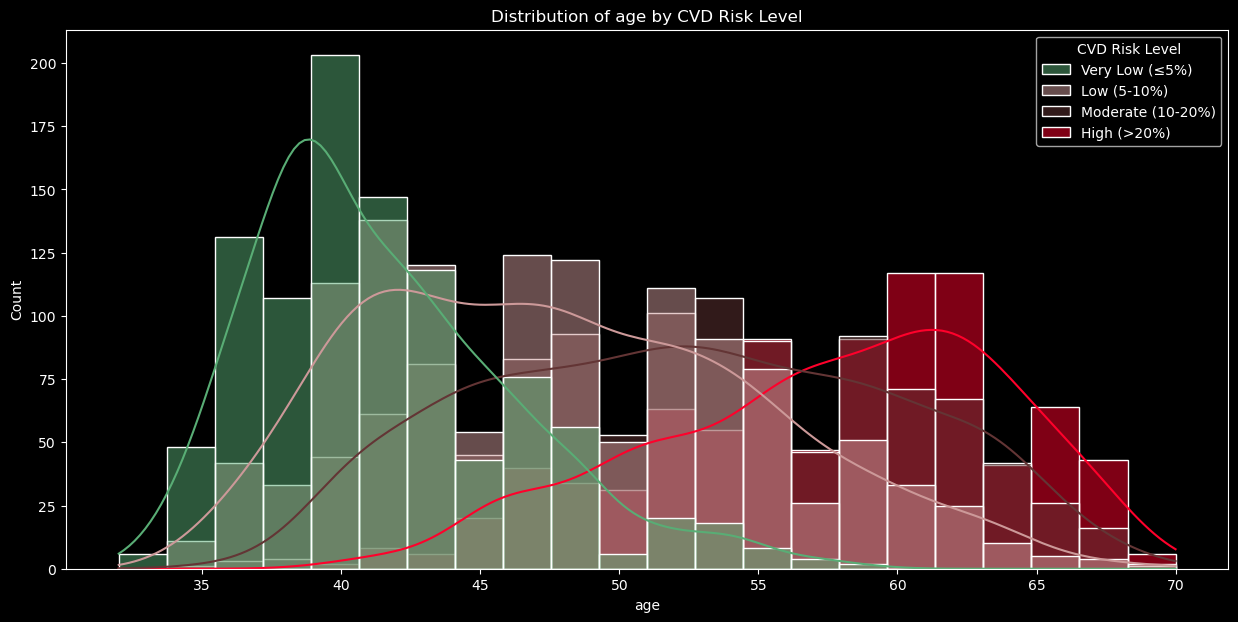

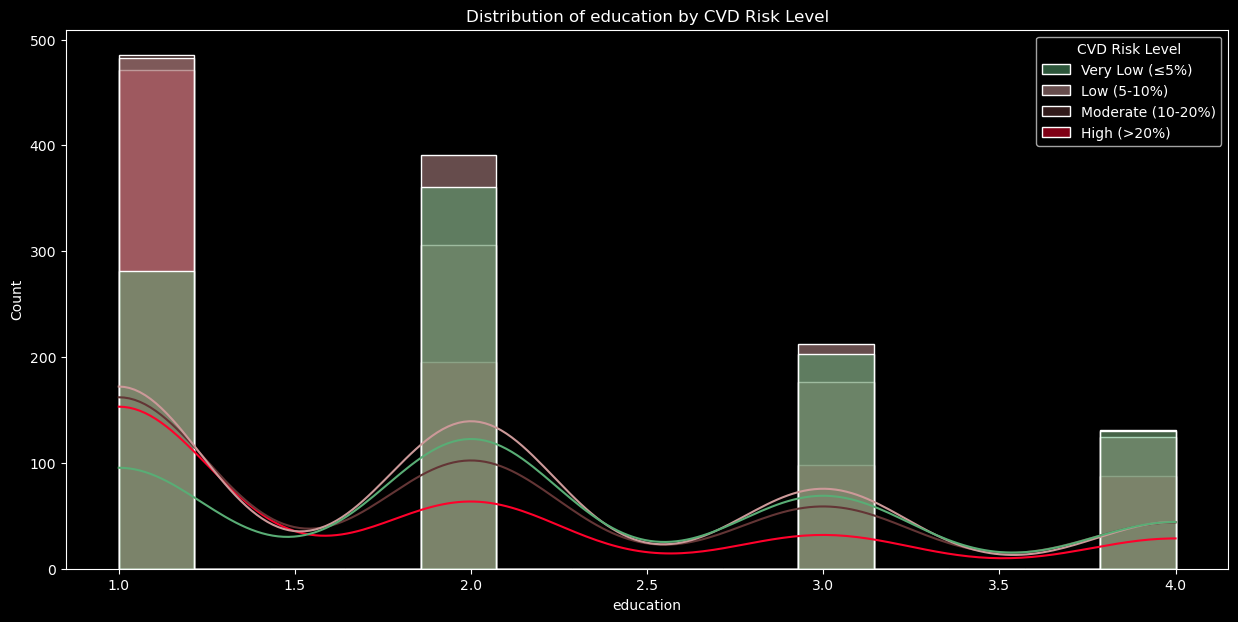

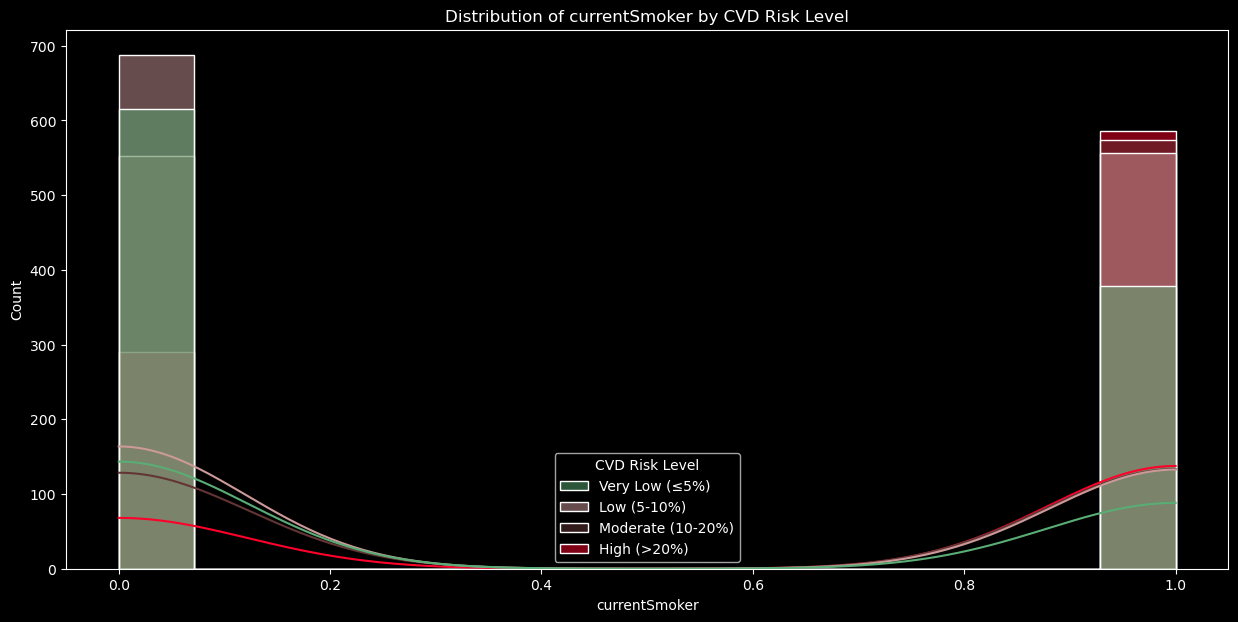

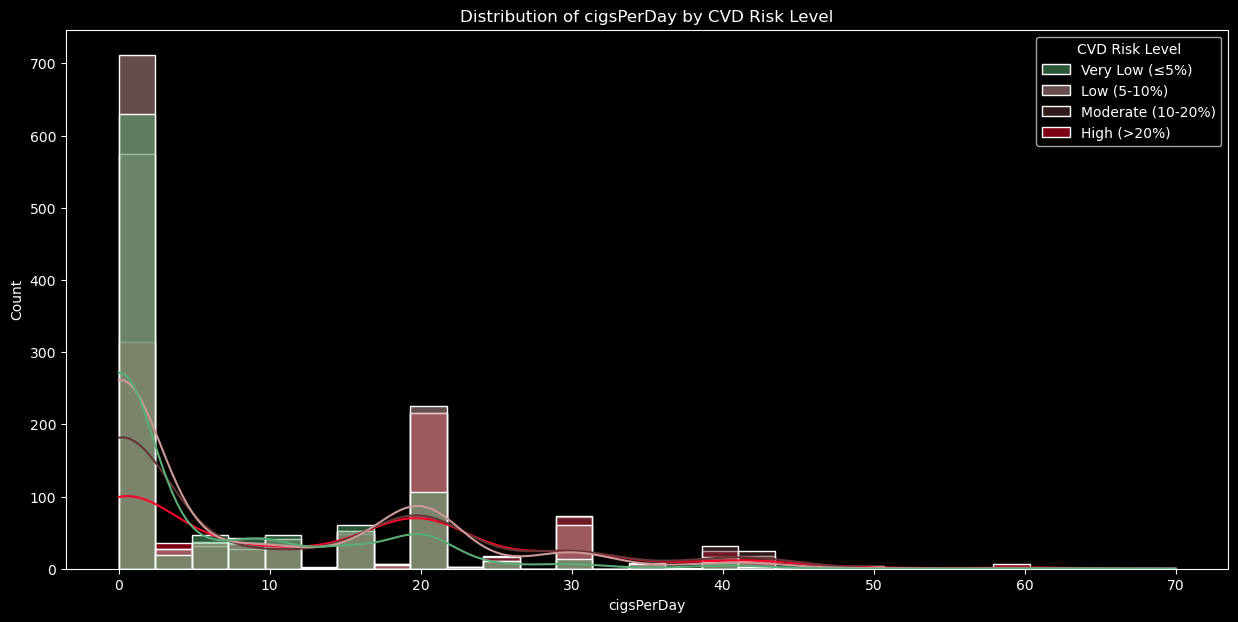

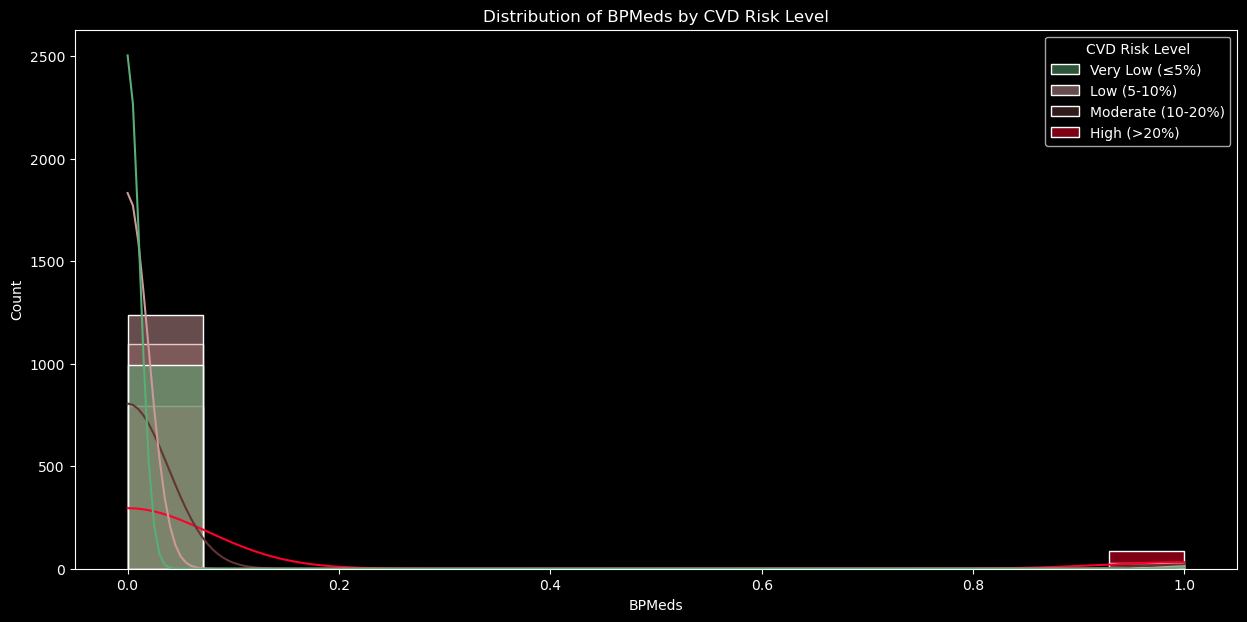

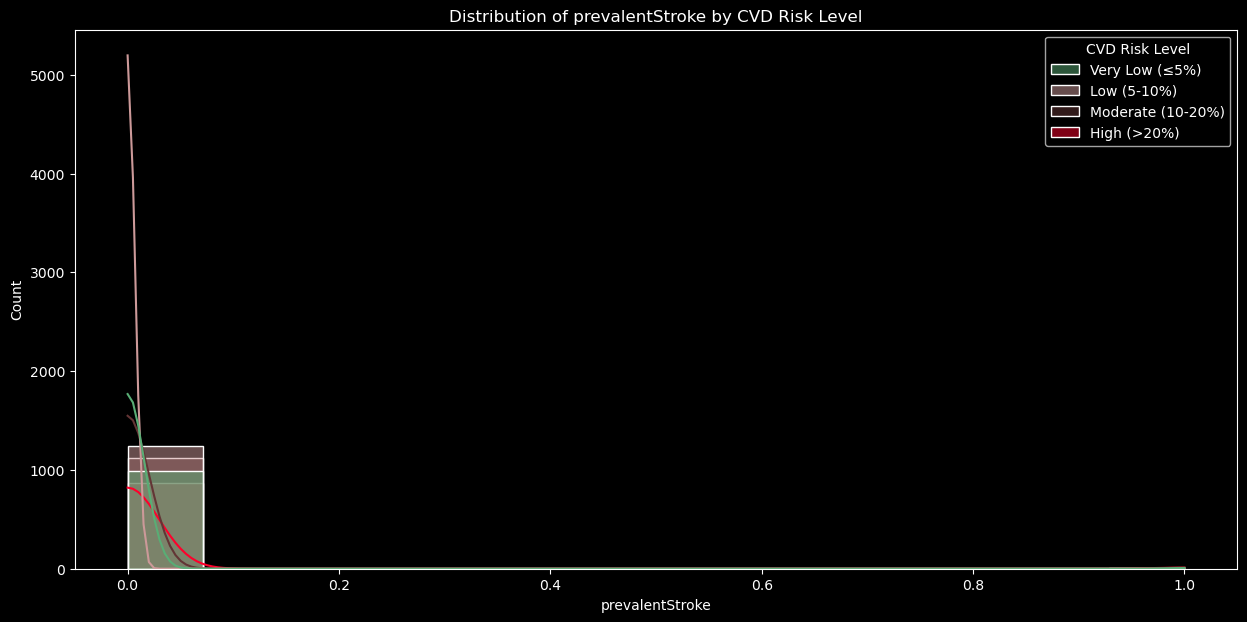

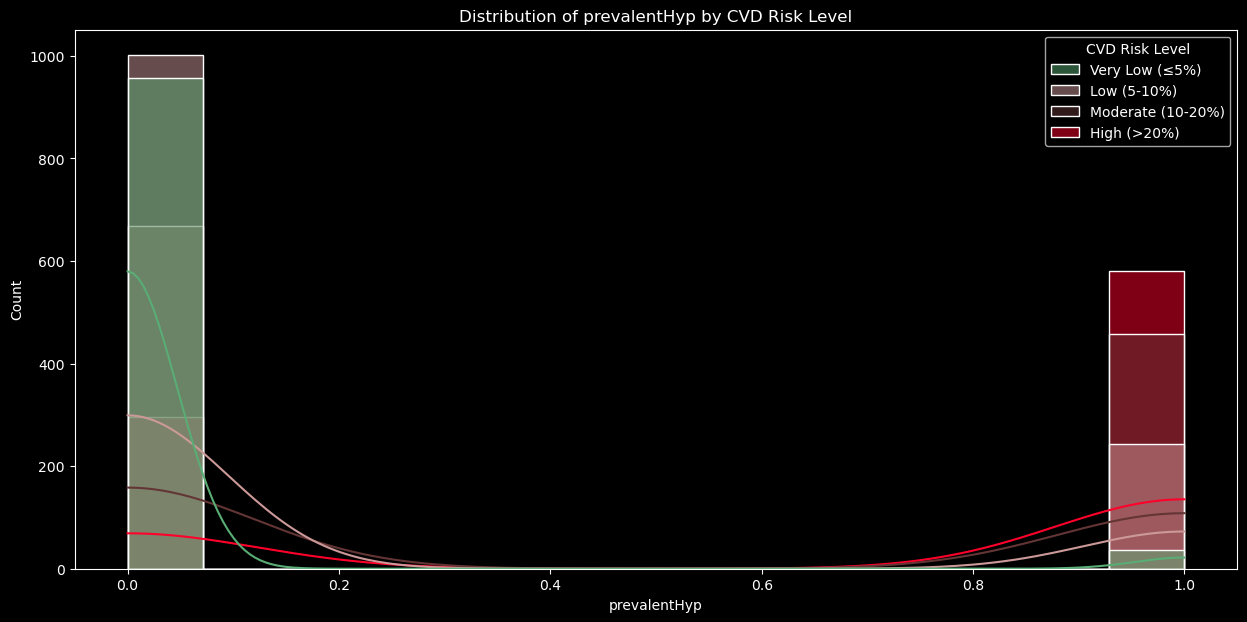

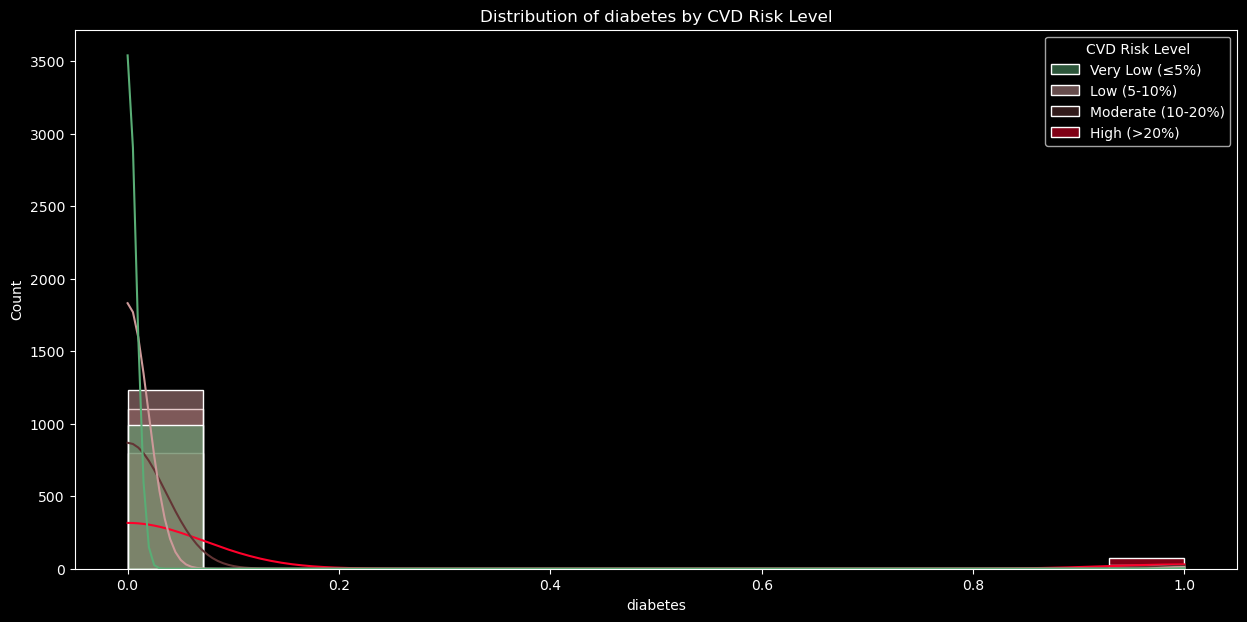

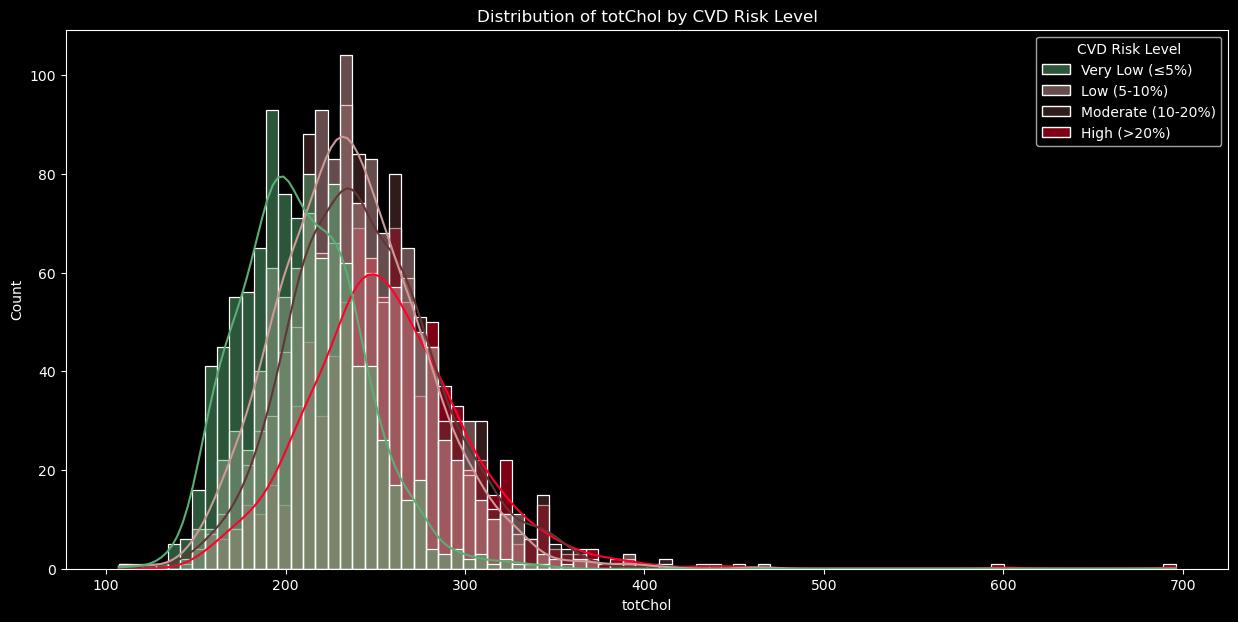

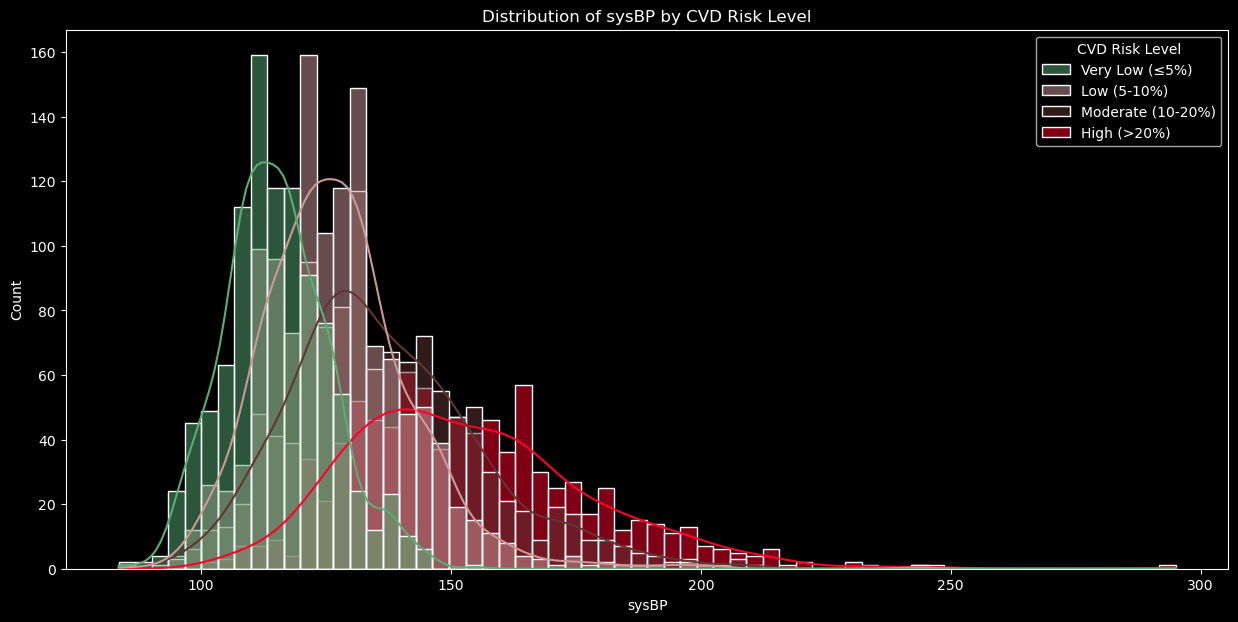

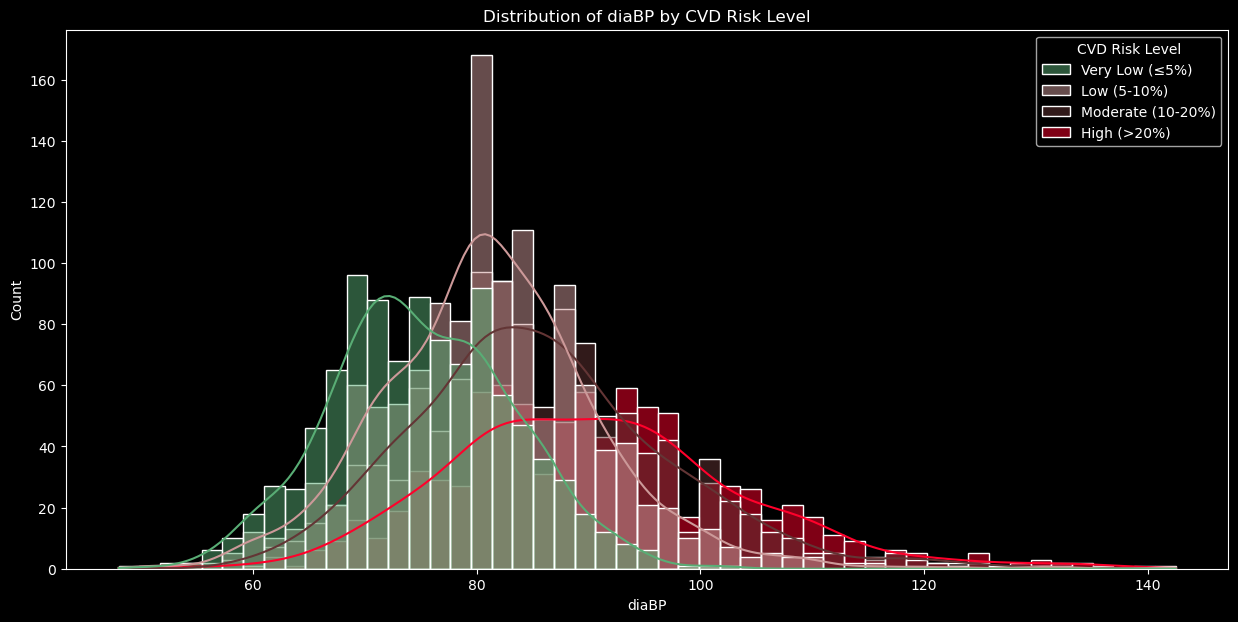

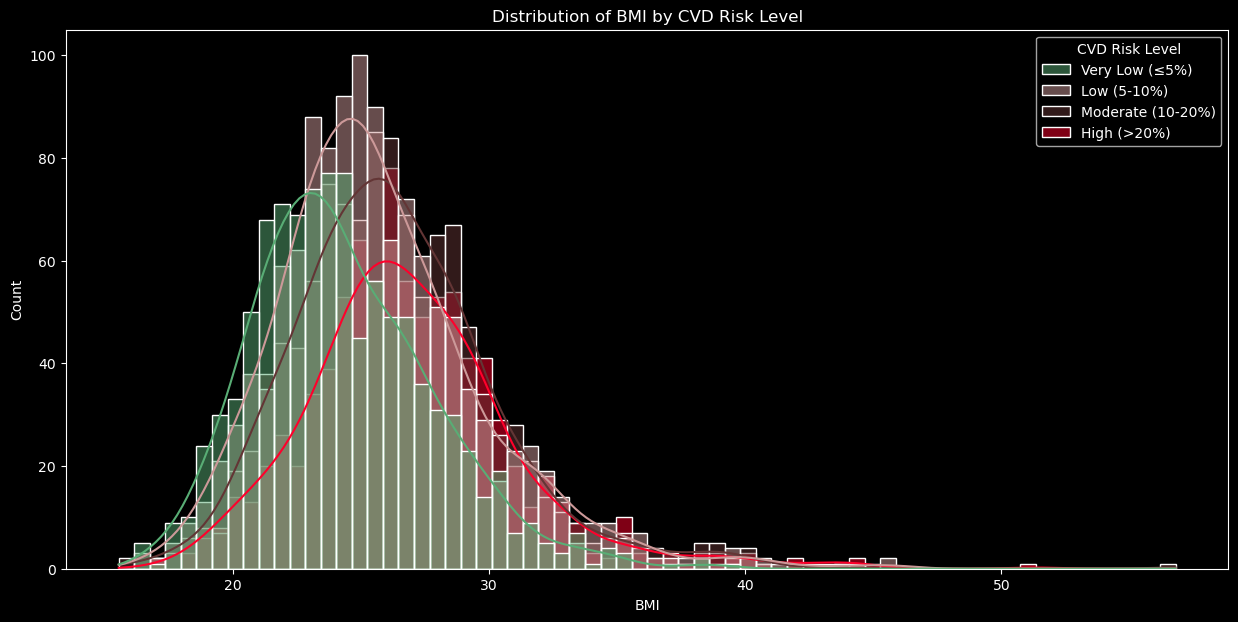

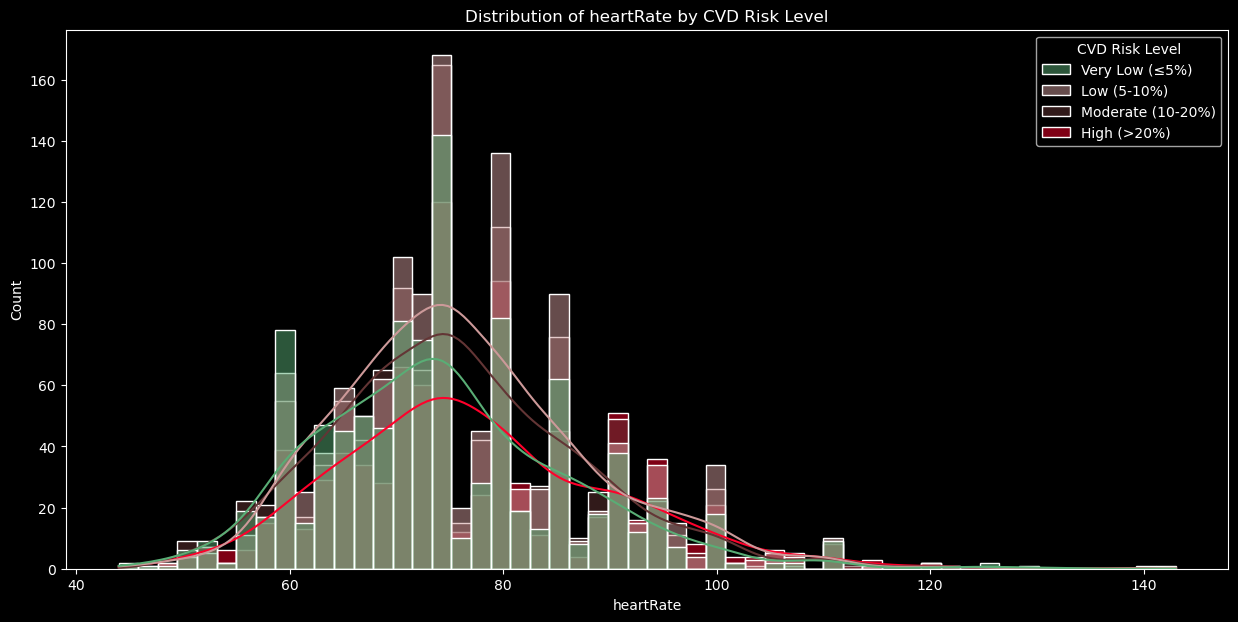

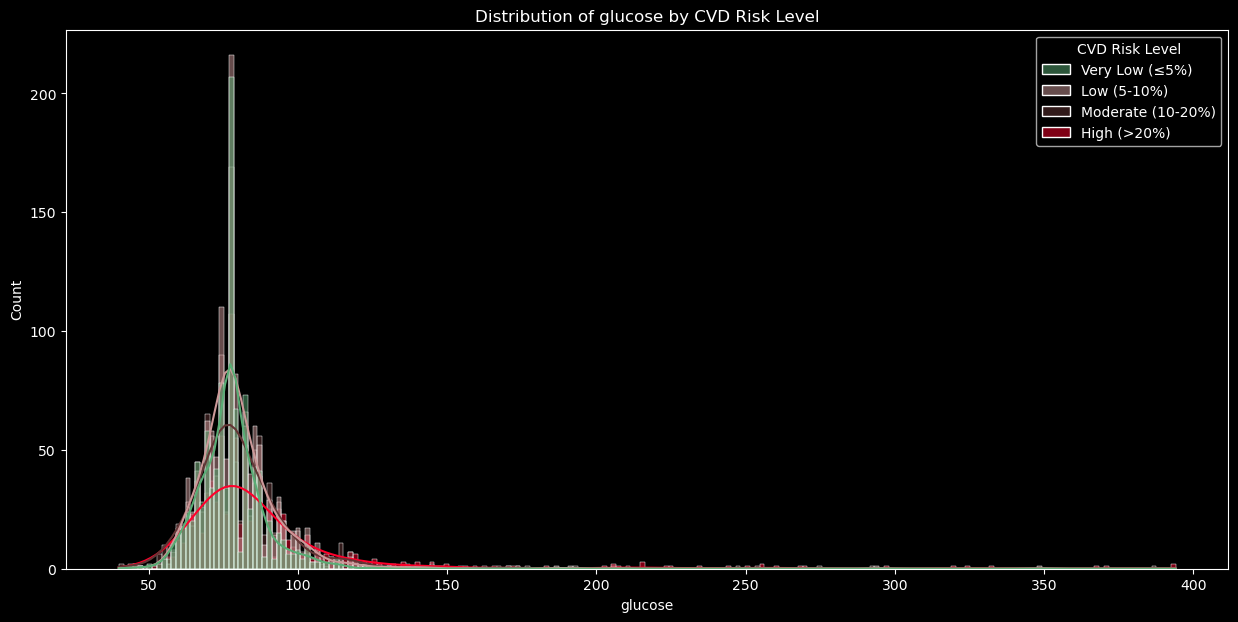

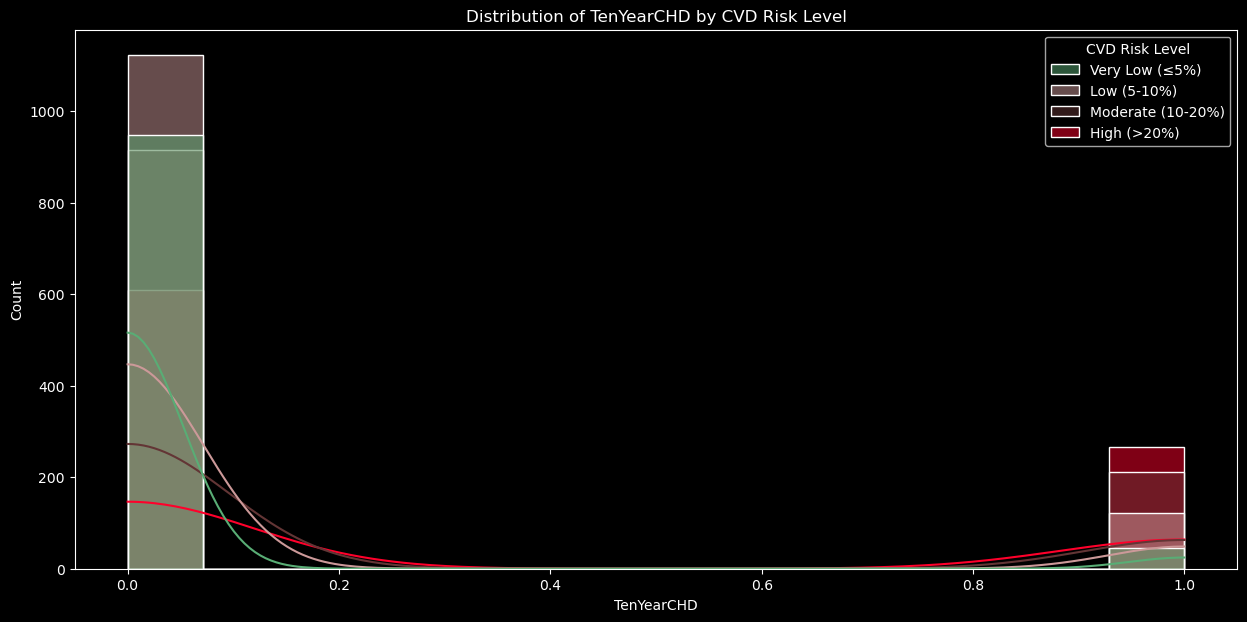

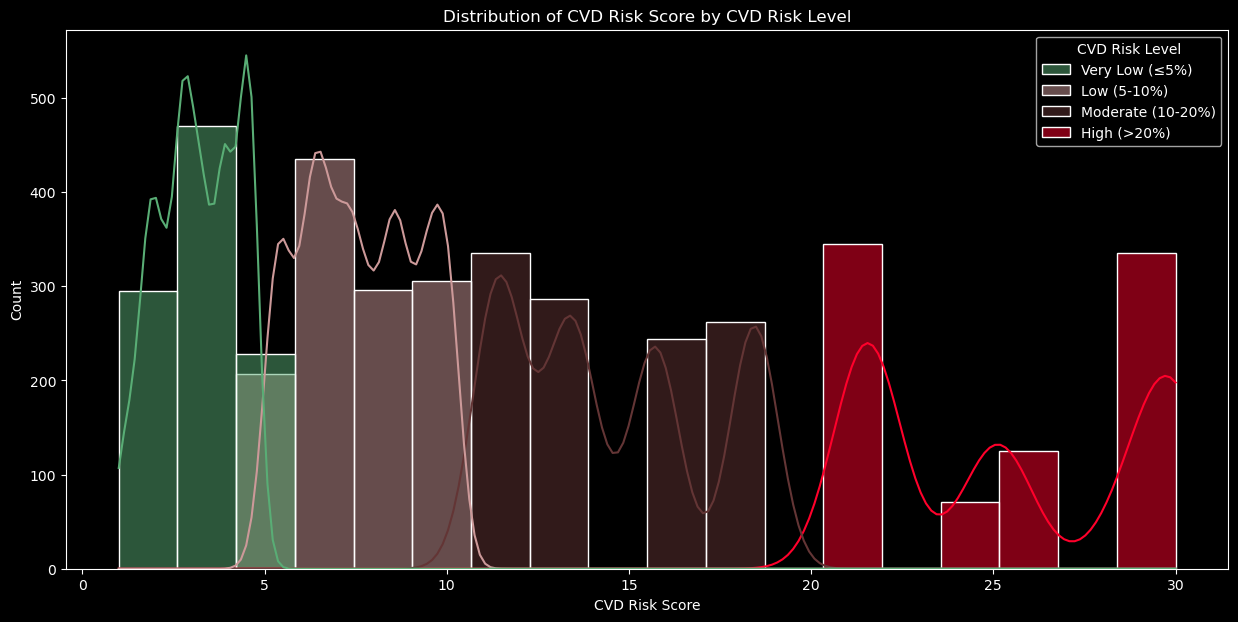

In [23]:
for col in df:
        if df[col].dtypes != 'object':
            plt.figure(figsize=(15,7))
            sns.histplot(data=df, x=col, hue= df['CVD Risk Level'], kde=True ,palette= custom_palette)
            plt.title(f'Distribution of {col} by CVD Risk Level')
            plt.show()

Plotting CVD Risk Score distributions grouped by categorical features...


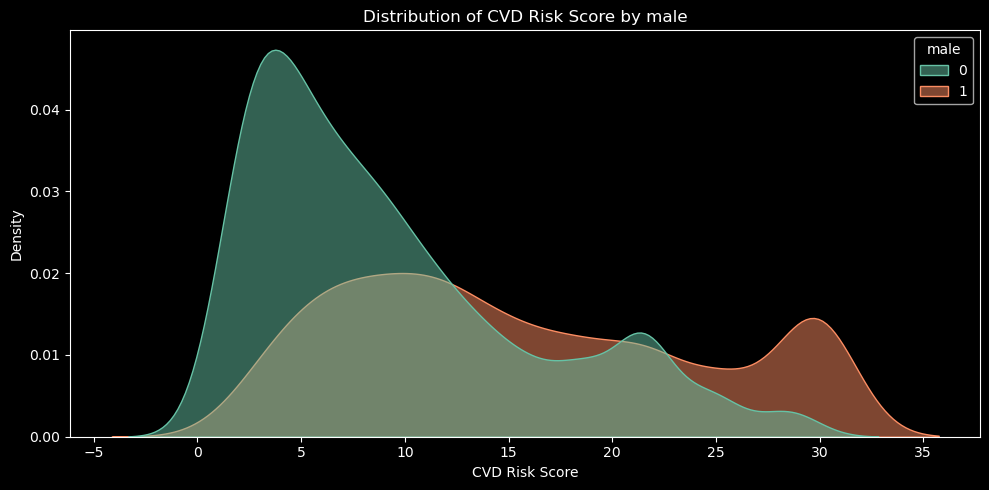

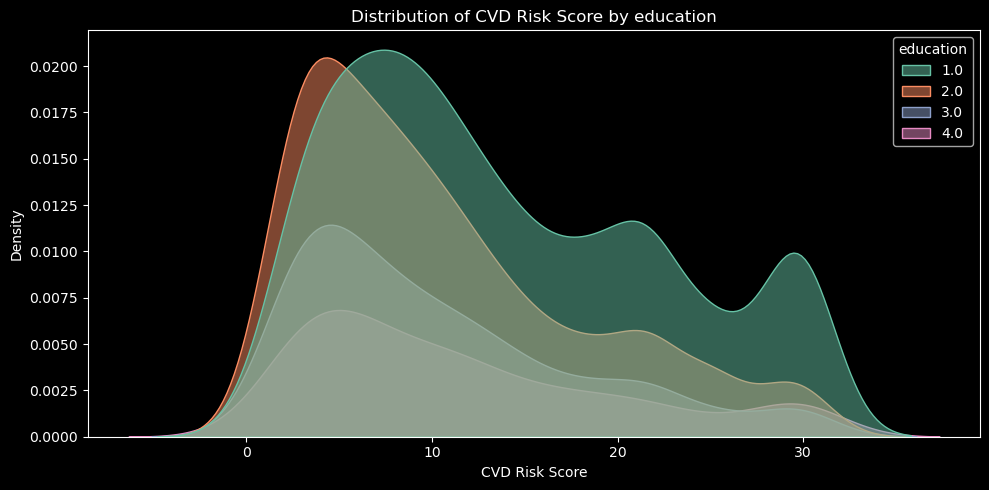

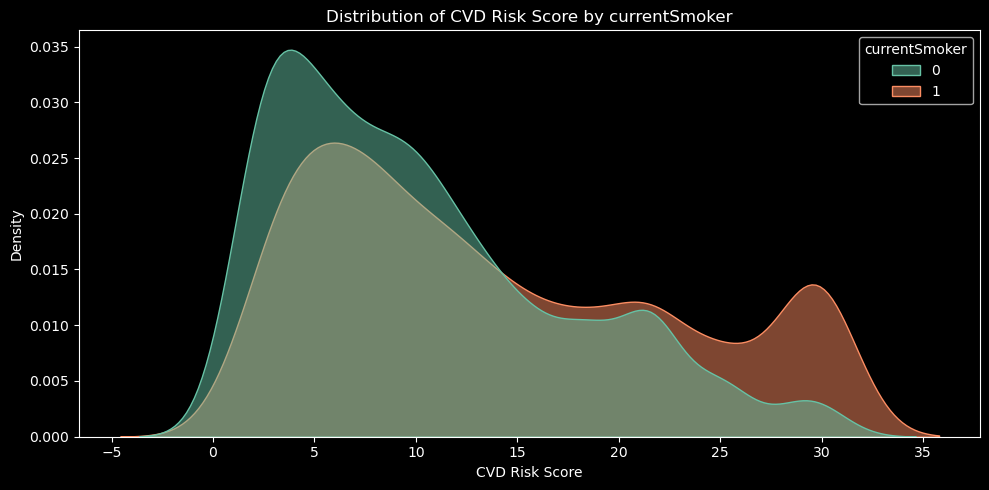

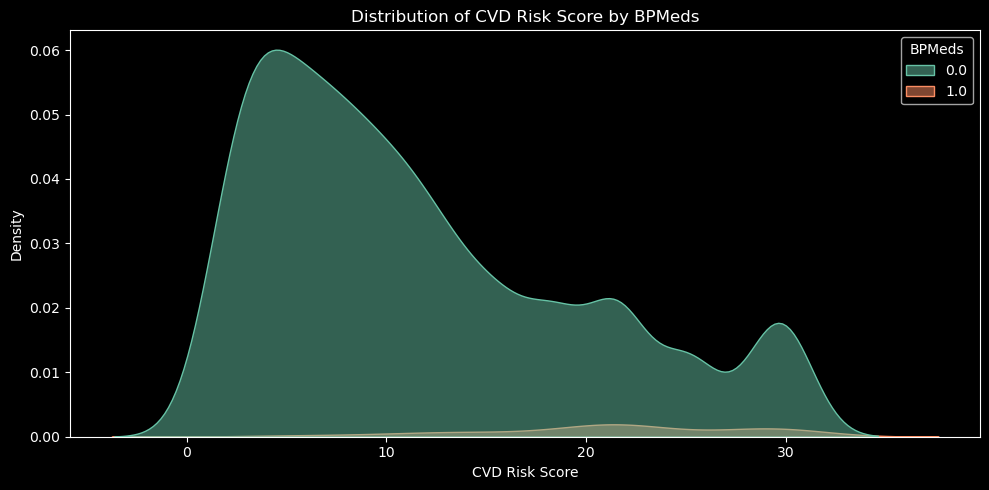

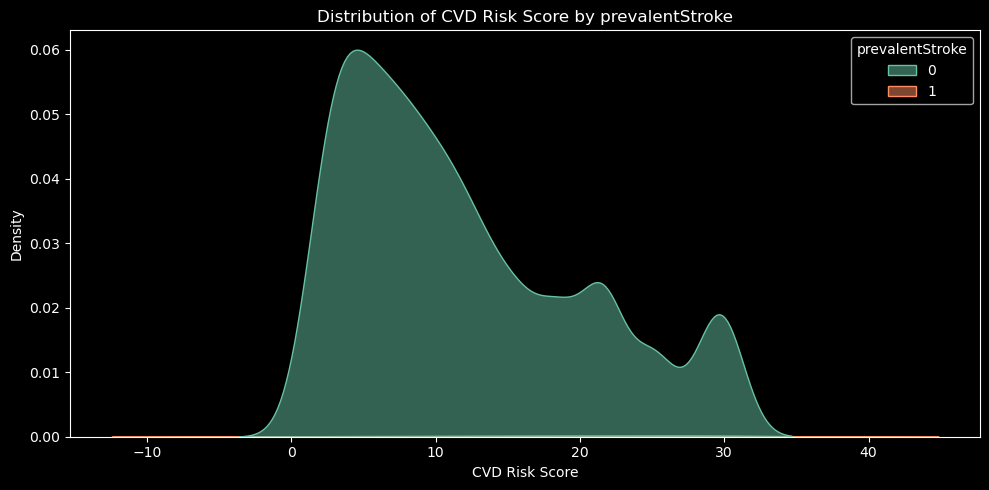

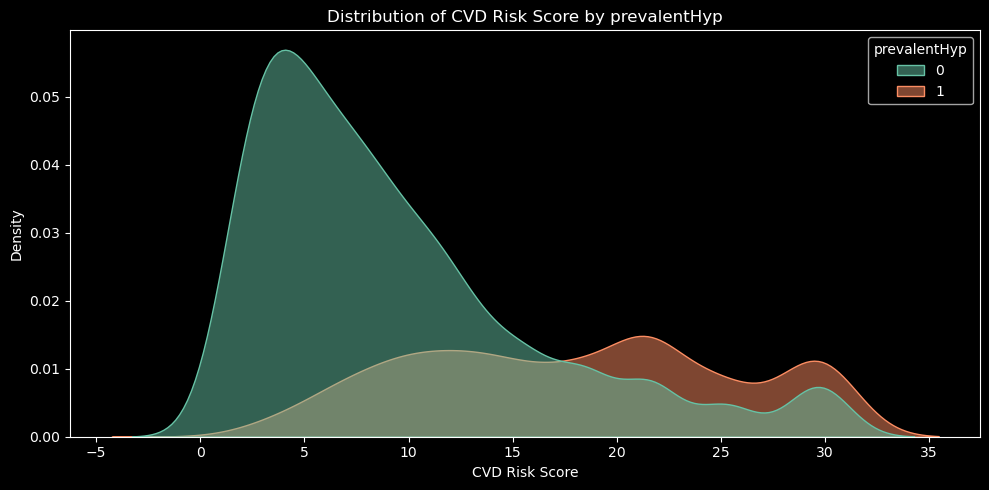

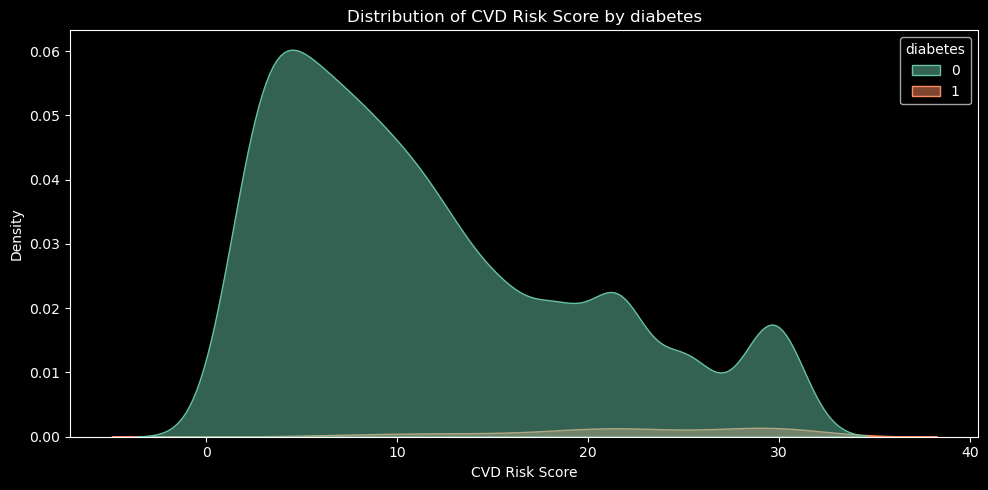

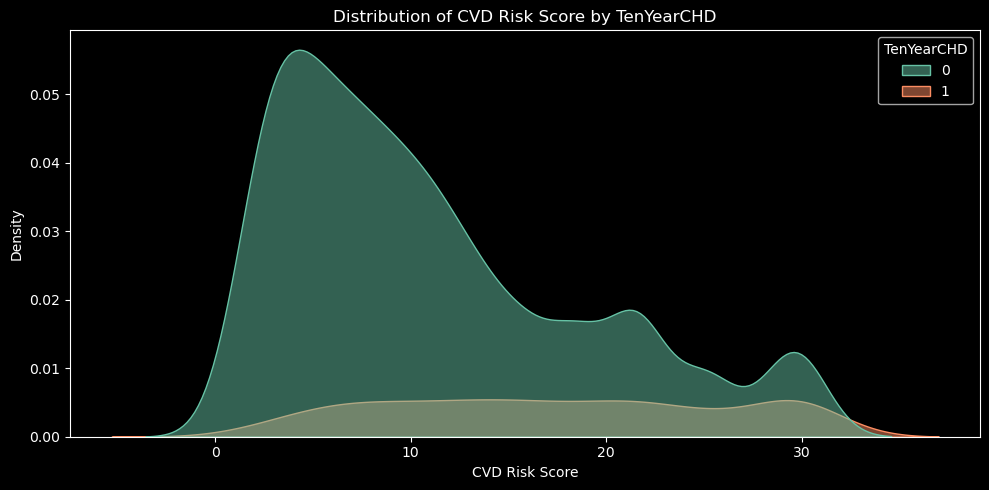

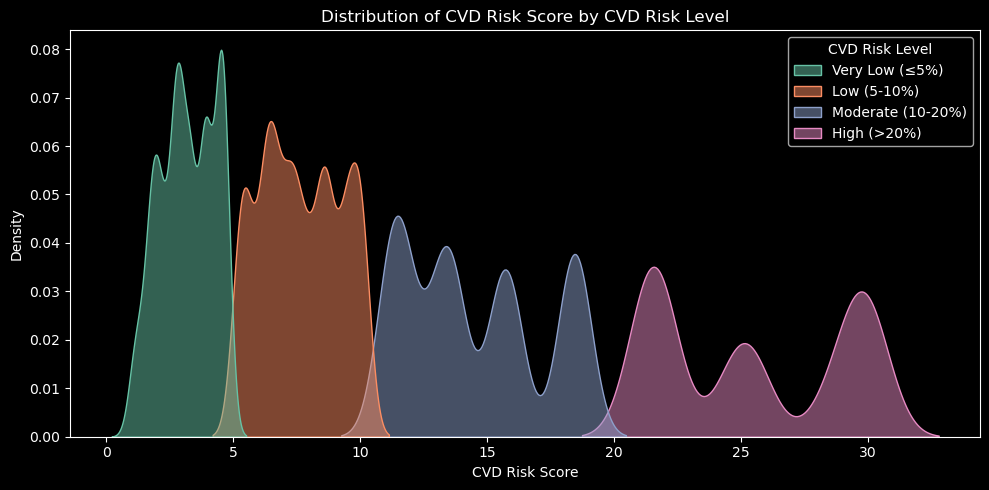

In [24]:
print(f"Plotting {'CVD Risk Score'} distributions grouped by categorical features...")
for col in df: 
 if df[col].nunique() <= 6 :
    plt.figure(figsize=(10, 5))
    sns.kdeplot(
        data=df.dropna(subset=['CVD Risk Score', col]),
        x='CVD Risk Score',
        hue=col,
        fill=True,
        palette='Set2',
        alpha=0.5
    )
    plt.title(f'Distribution of {'CVD Risk Score'} by {col}')
    plt.tight_layout()
    plt.show()

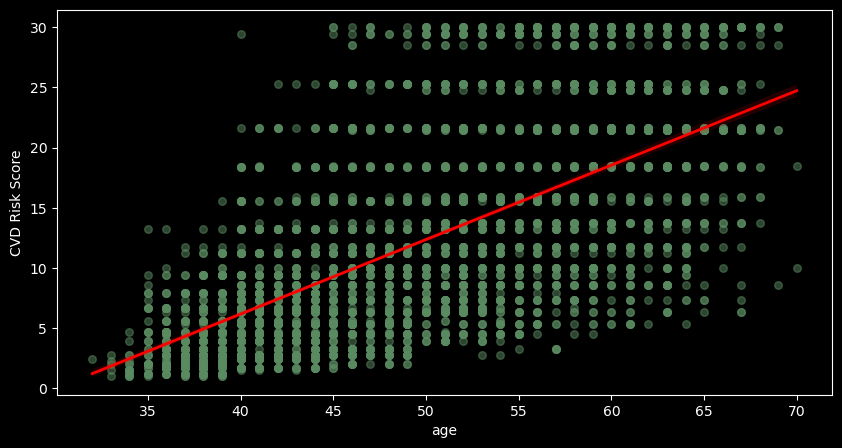

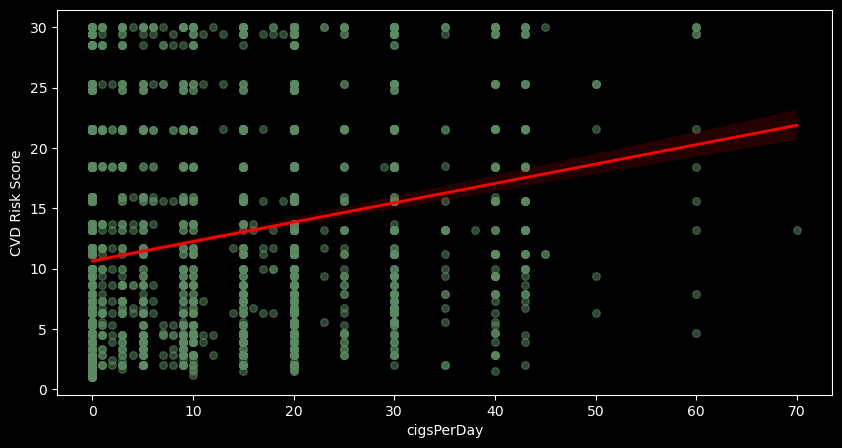

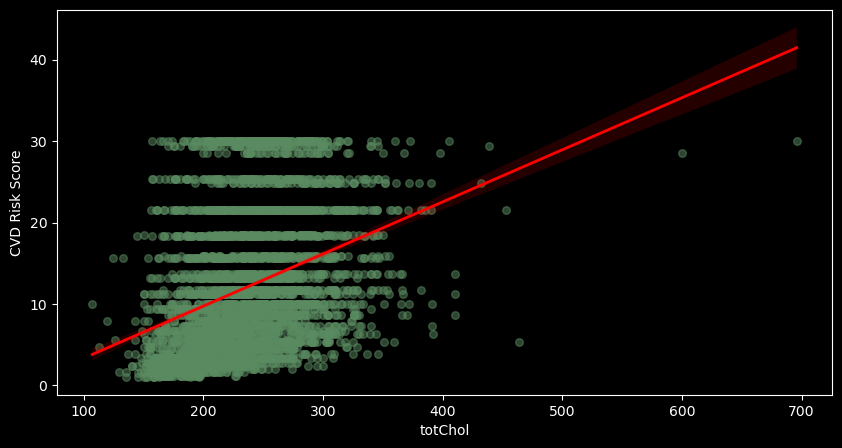

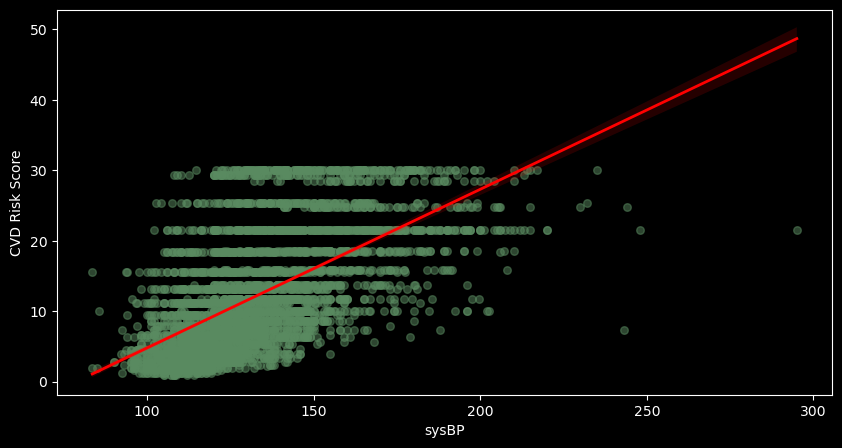

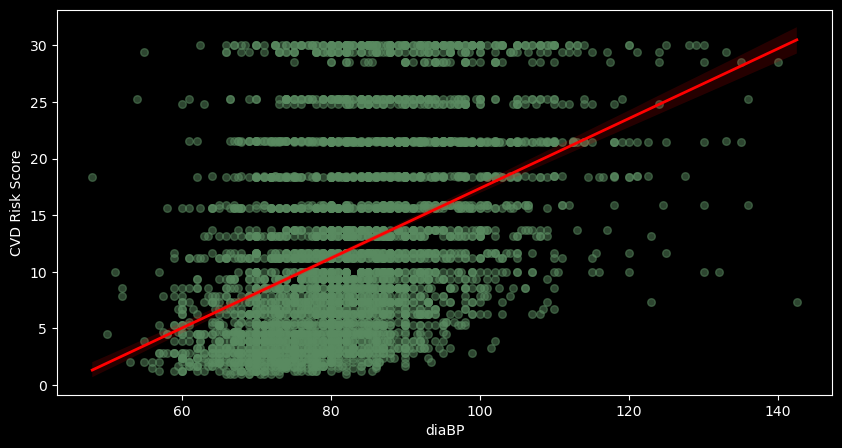

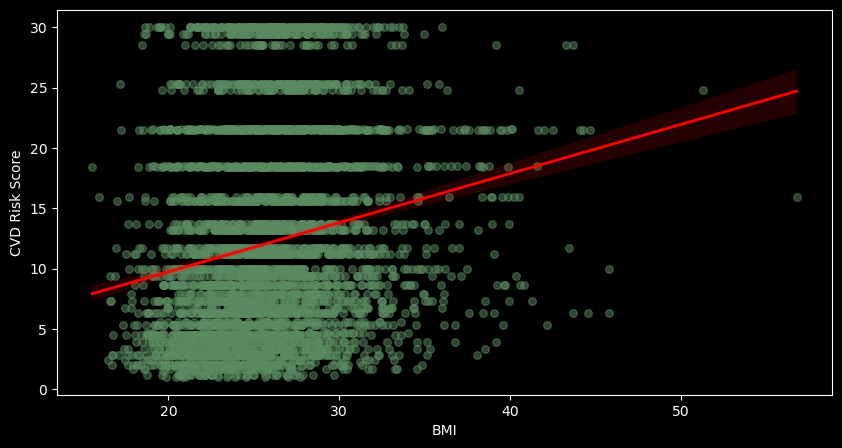

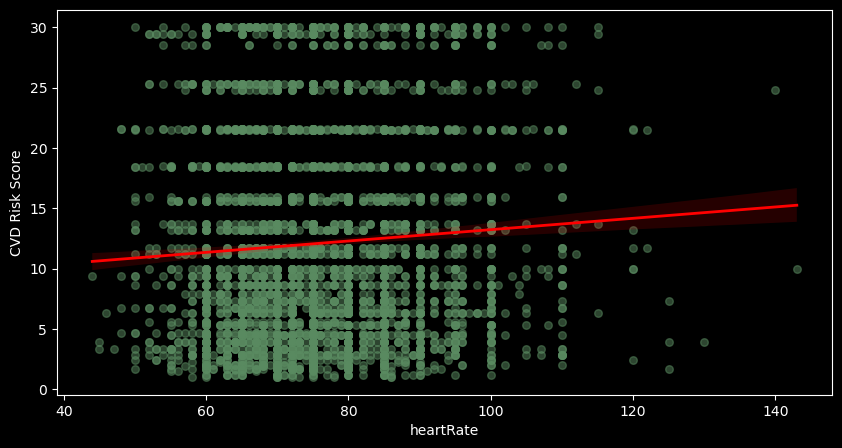

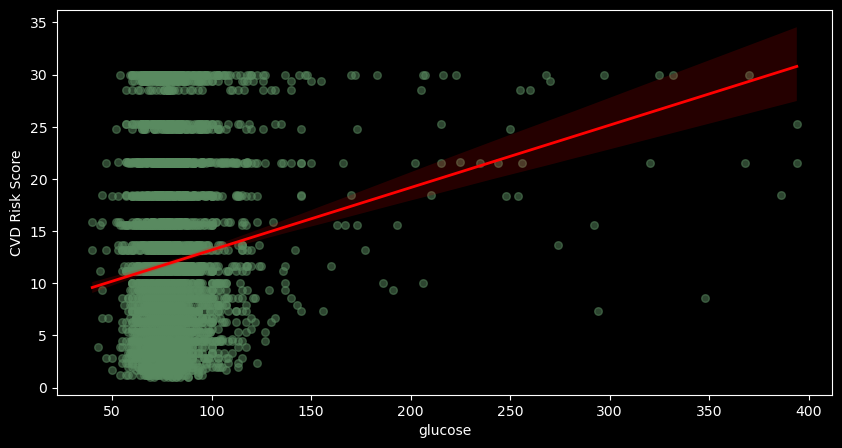

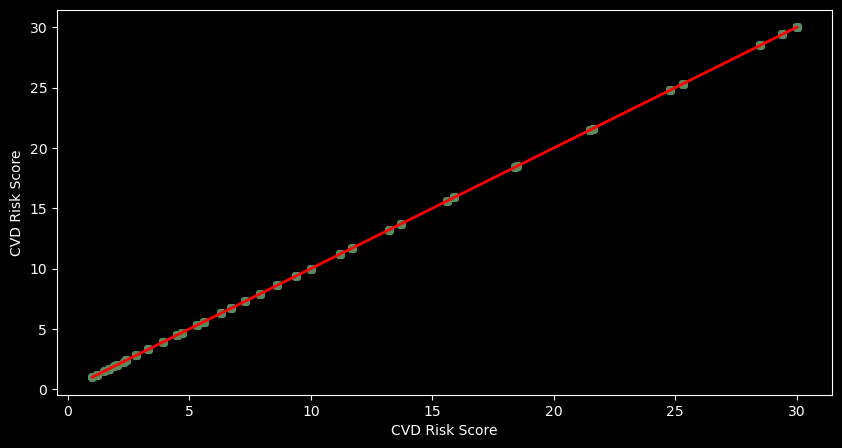

In [25]:
for col in df :
 if df[col].nunique() > 6 :
    plt.figure(figsize=(10, 5))
    sns.regplot(
        data=df,
        x=col,       
        y='CVD Risk Score',     
        scatter_kws={'alpha': 0.5, 's': 30, 'color': "#5A8B61"}, 
        line_kws={'linestyle': '-', 'linewidth': 2, 'color': 'red'} 
    )

C:\Users\bad nerd\AppData\Local\Temp\ipykernel_11764\4076002355.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


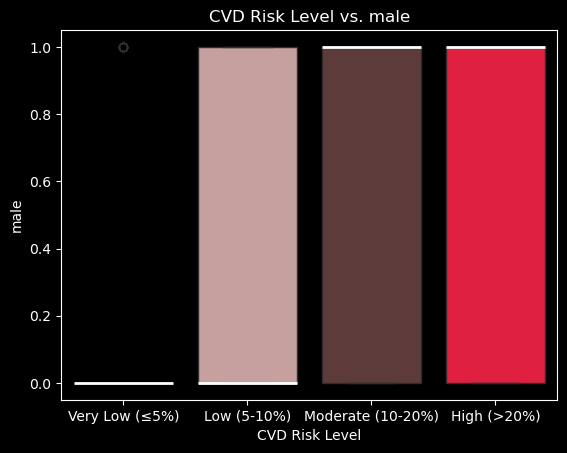

C:\Users\bad nerd\AppData\Local\Temp\ipykernel_11764\4076002355.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


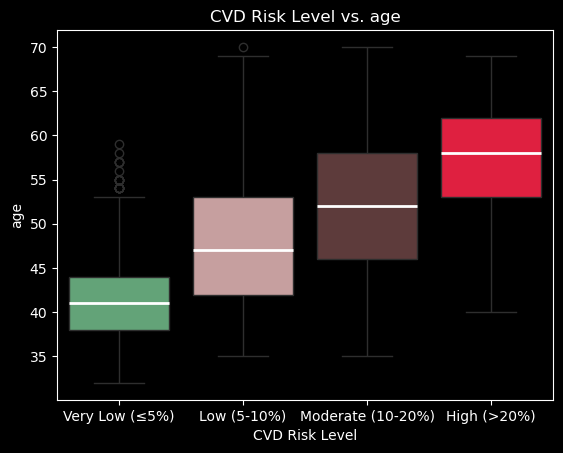

C:\Users\bad nerd\AppData\Local\Temp\ipykernel_11764\4076002355.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


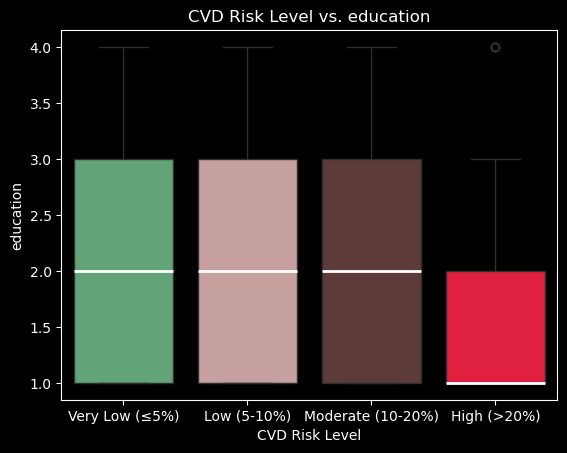

C:\Users\bad nerd\AppData\Local\Temp\ipykernel_11764\4076002355.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


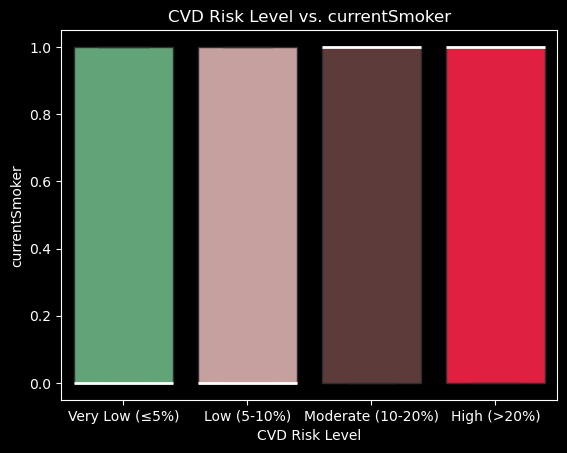

C:\Users\bad nerd\AppData\Local\Temp\ipykernel_11764\4076002355.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


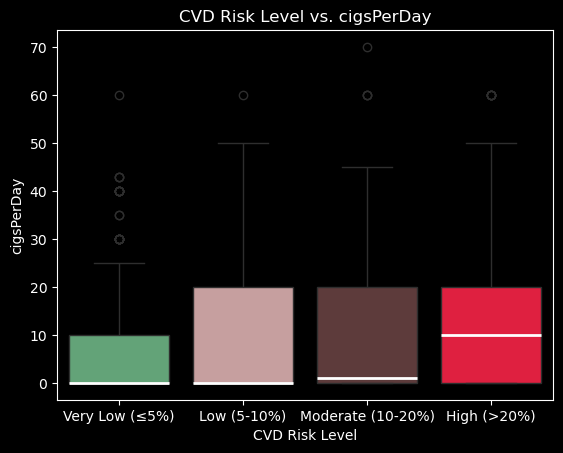

C:\Users\bad nerd\AppData\Local\Temp\ipykernel_11764\4076002355.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


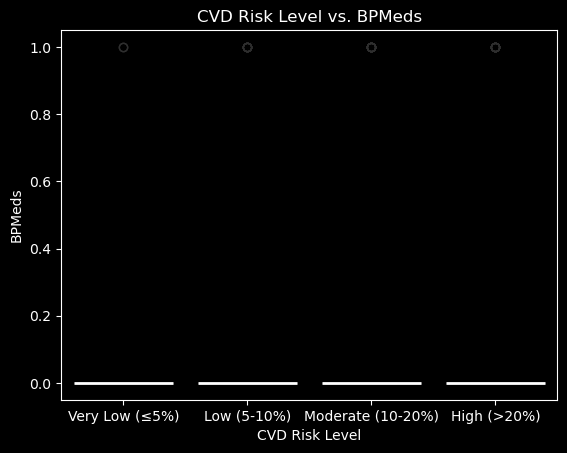

C:\Users\bad nerd\AppData\Local\Temp\ipykernel_11764\4076002355.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


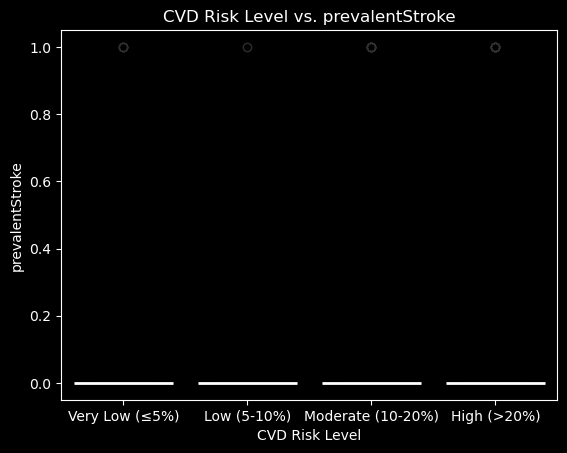

C:\Users\bad nerd\AppData\Local\Temp\ipykernel_11764\4076002355.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


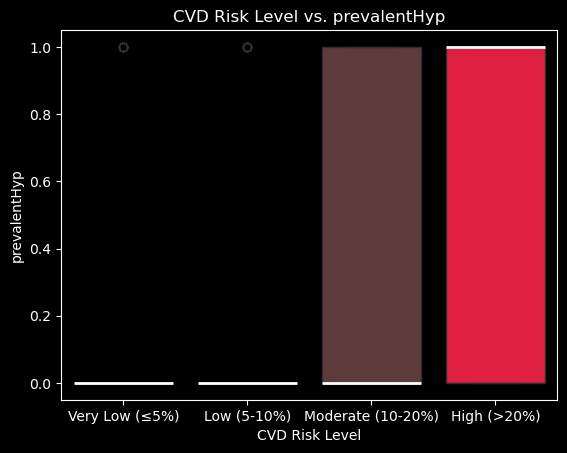

C:\Users\bad nerd\AppData\Local\Temp\ipykernel_11764\4076002355.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


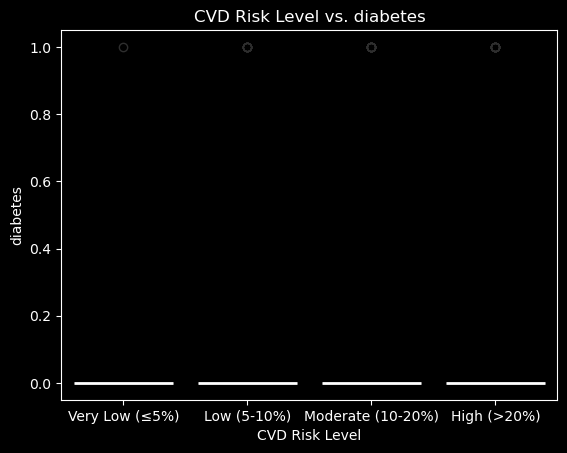

C:\Users\bad nerd\AppData\Local\Temp\ipykernel_11764\4076002355.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


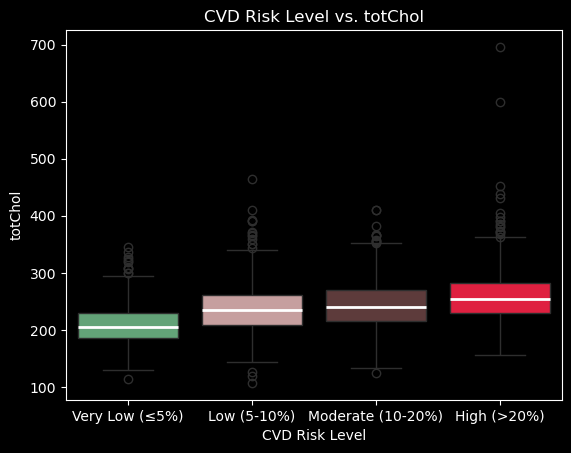

C:\Users\bad nerd\AppData\Local\Temp\ipykernel_11764\4076002355.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


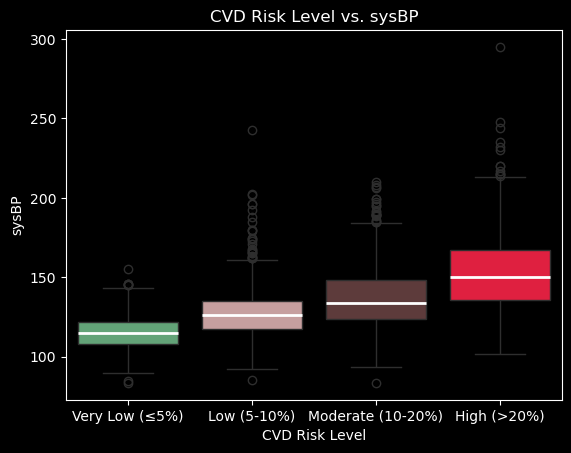

C:\Users\bad nerd\AppData\Local\Temp\ipykernel_11764\4076002355.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


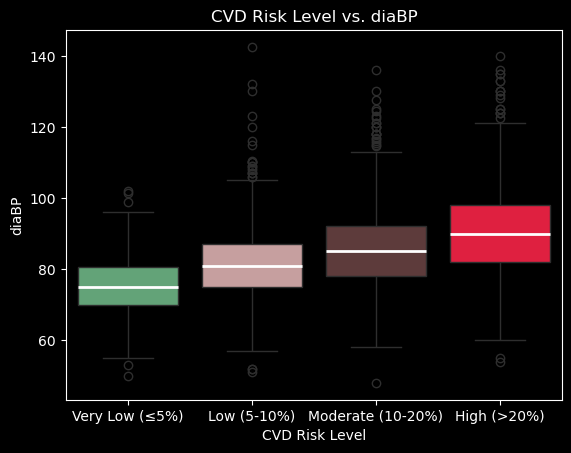

C:\Users\bad nerd\AppData\Local\Temp\ipykernel_11764\4076002355.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


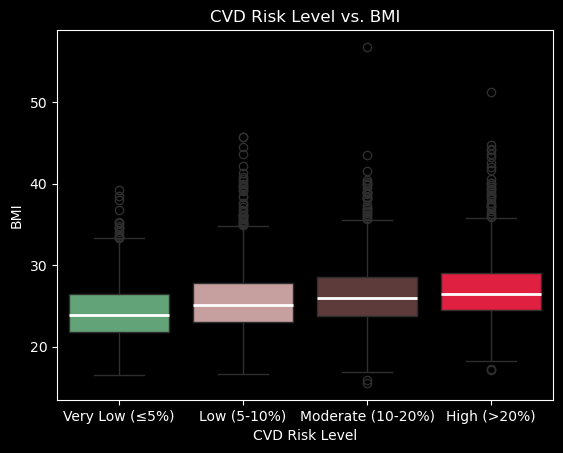

C:\Users\bad nerd\AppData\Local\Temp\ipykernel_11764\4076002355.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


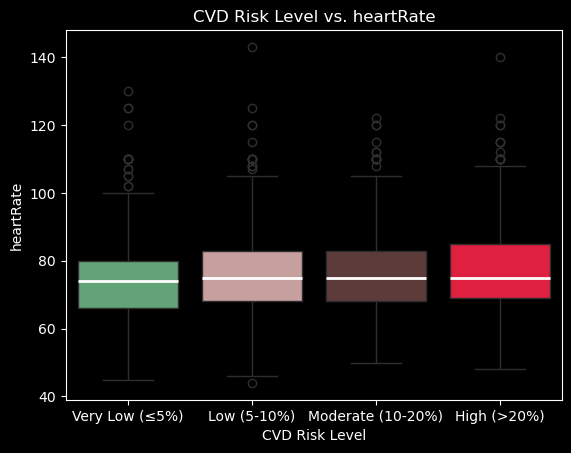

C:\Users\bad nerd\AppData\Local\Temp\ipykernel_11764\4076002355.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


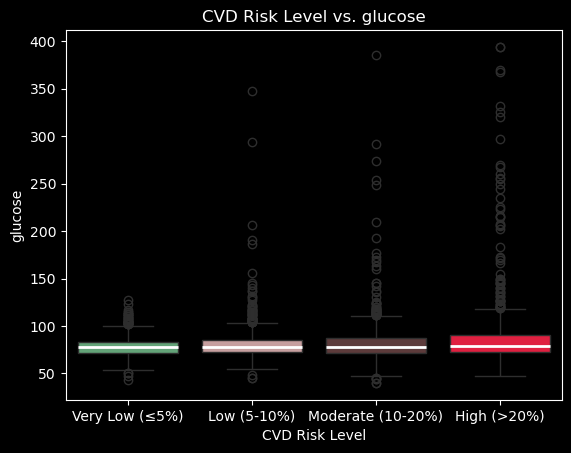

C:\Users\bad nerd\AppData\Local\Temp\ipykernel_11764\4076002355.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


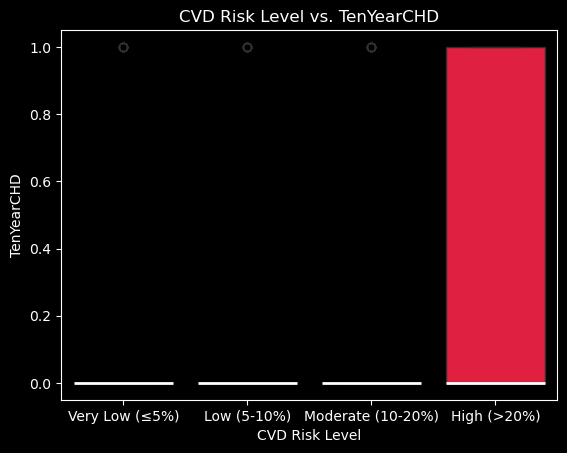

C:\Users\bad nerd\AppData\Local\Temp\ipykernel_11764\4076002355.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


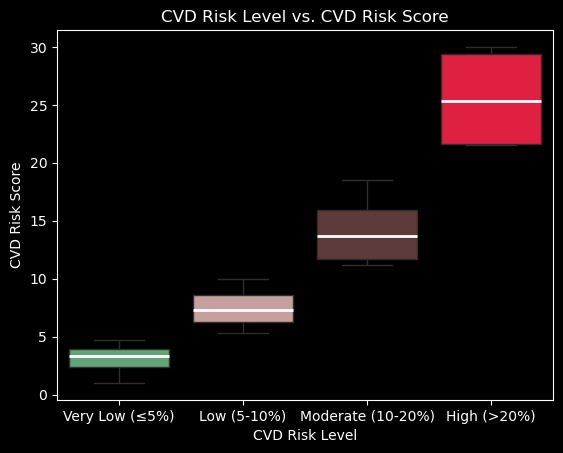

In [26]:
for col in df:
    if df[col].dtype != 'object':
        plt.figure()
        sns.boxplot(
            data=df, 
            x=df['CVD Risk Level'],
            y=col,
            medianprops={'color': 'white', 'linewidth': 2},
            palette= custom_palette
                    )
        plt.title(f'CVD Risk Level vs. {col}')
        plt.show()

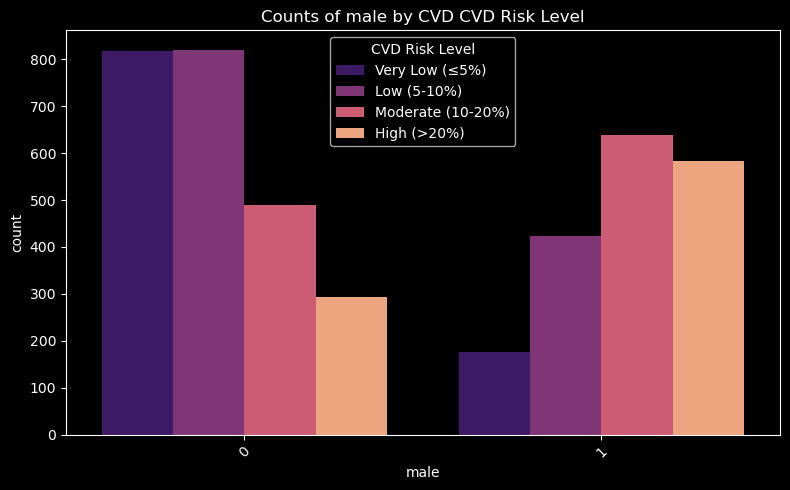

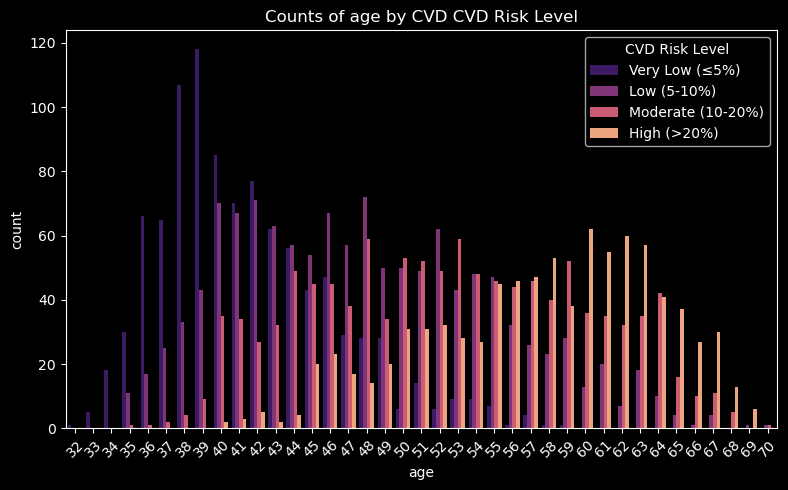

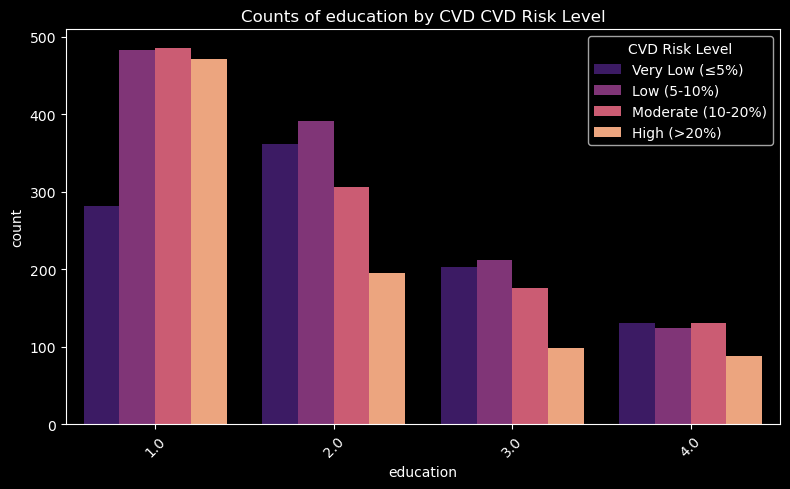

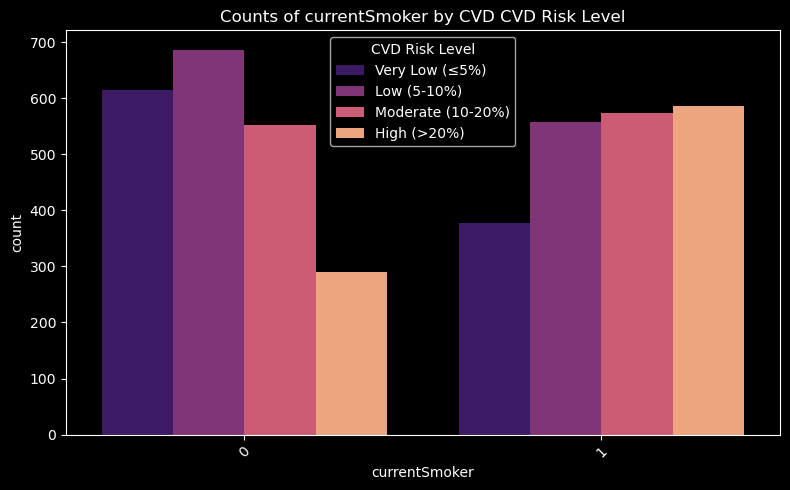

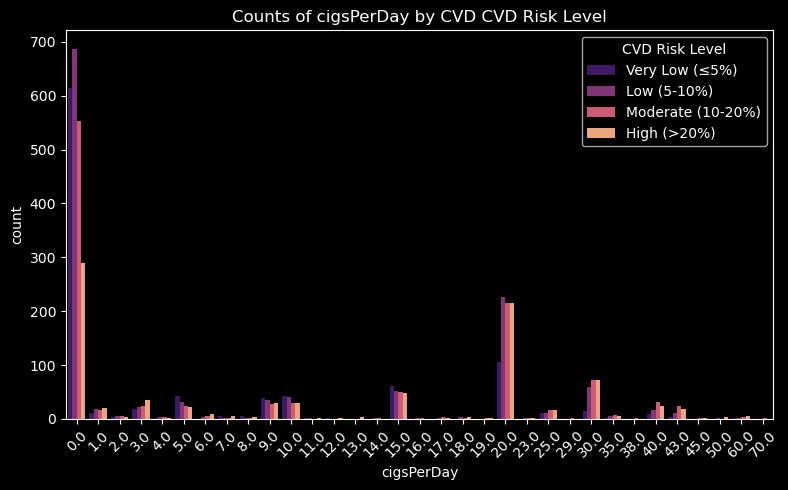

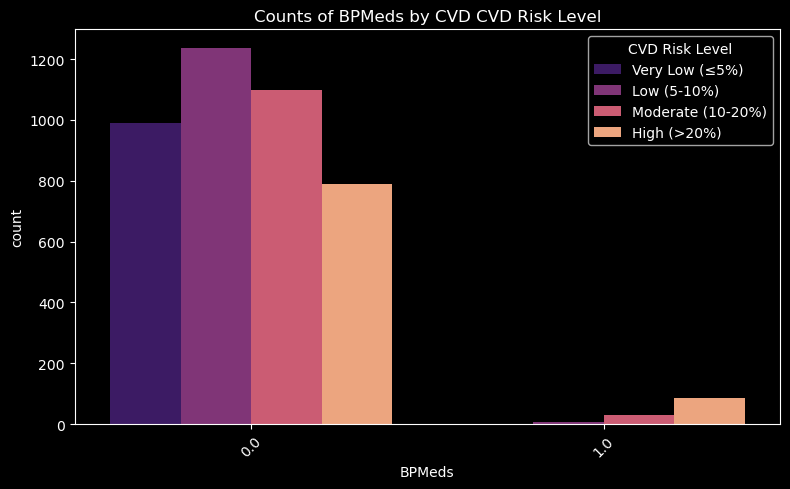

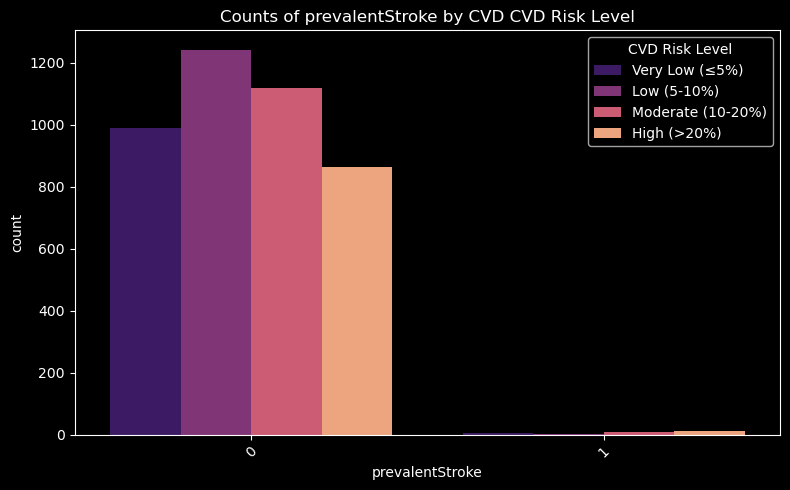

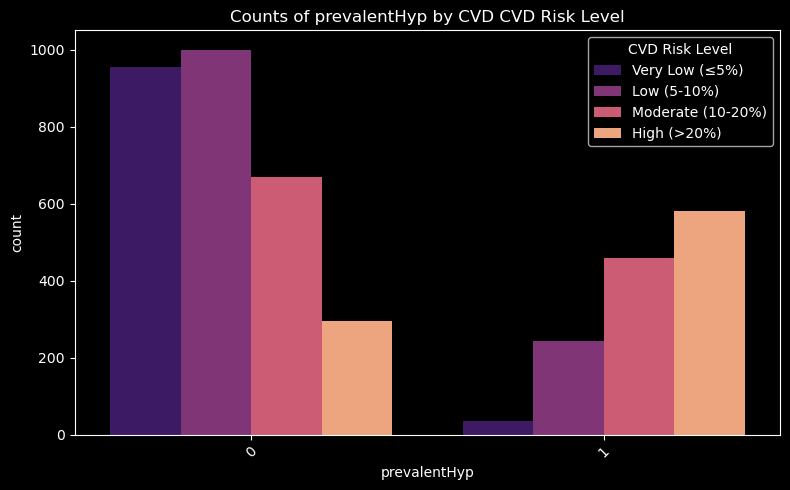

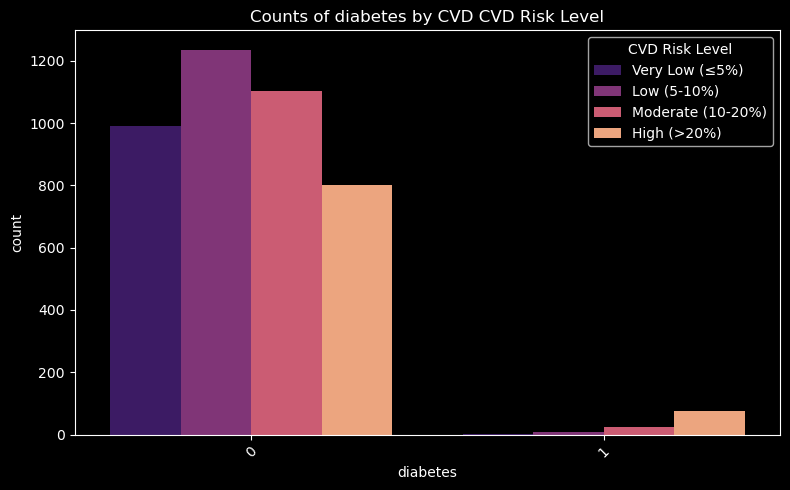

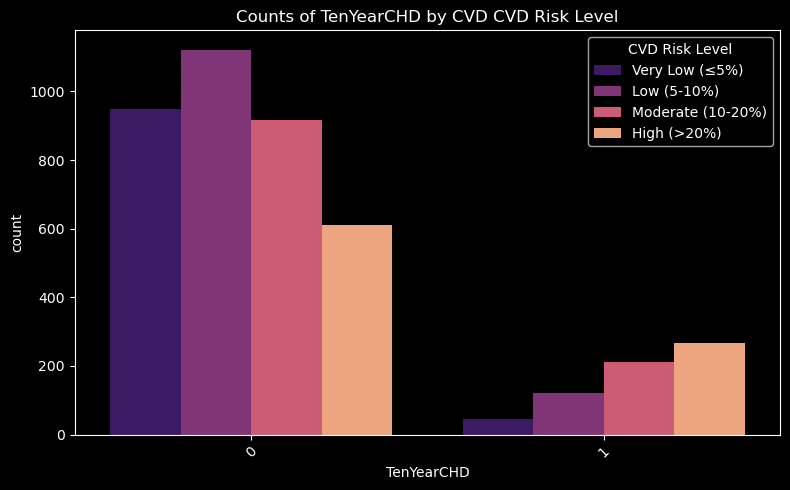

In [27]:
exclude_cols = ['totChol', 'sysBP', 'diaBP', 'BMI', 'heartRate', 'glucose', 'CVD Risk Score', 'CVD Risk Level']

# Loop through columns and plot counts against CVD Risk Level
for col in df.columns:
    if col not in exclude_cols:
        plt.figure(figsize=(8, 5))
        sns.countplot(
            data=df, 
            x=col, 
            hue='CVD Risk Level', 
            hue_order=order,
            palette='magma'
        ) 
        plt.title(f'Counts of {col} by CVD CVD Risk Level')
        plt.xticks(rotation=45) 
        plt.tight_layout()
        plt.show()

In [28]:
df.columns

Index(['male', 'age', 'education', 'currentSmoker', 'cigsPerDay', 'BPMeds',
       'prevalentStroke', 'prevalentHyp', 'diabetes', 'totChol', 'sysBP',
       'diaBP', 'BMI', 'heartRate', 'glucose', 'TenYearCHD', 'CVD Risk Score',
       'CVD Risk Level'],
      dtype='object')

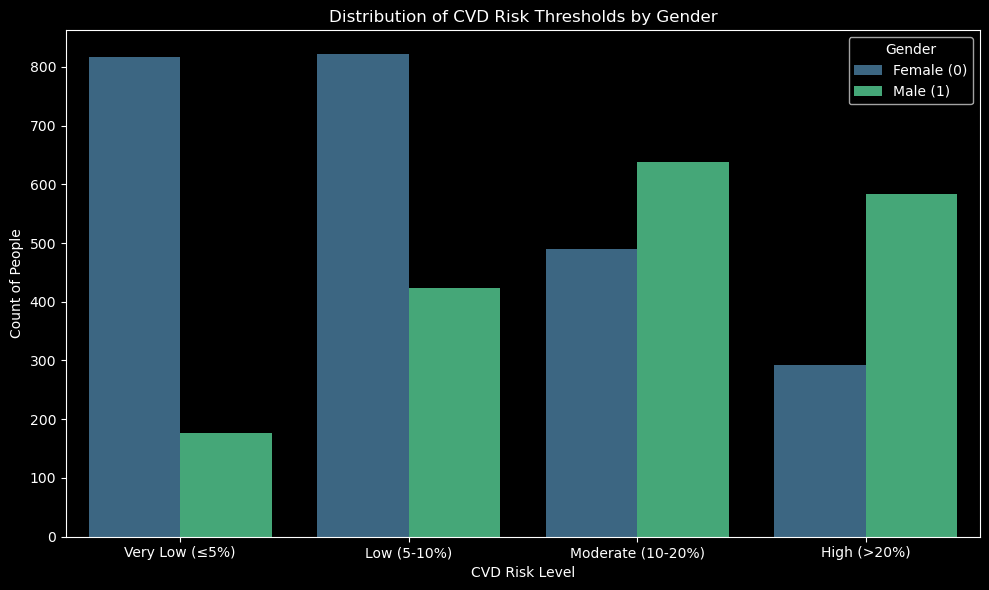

In [29]:
# Plotting
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='CVD Risk Level', hue='male', order=order, palette='viridis')

plt.title('Distribution of CVD Risk Thresholds by Gender')
plt.xlabel('CVD Risk Level')
plt.ylabel('Count of People')
plt.legend(title='Gender', labels=['Female (0)', 'Male (1)'])
plt.tight_layout()
plt.show()

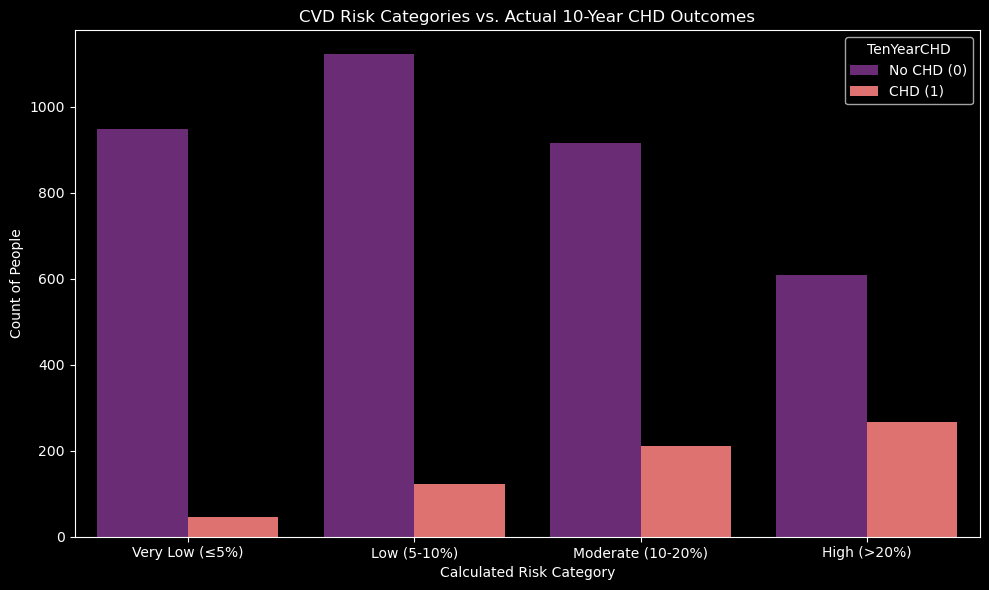

In [30]:
# Plotting the relationship with TenYearCHD
plt.figure(figsize=(10, 6))

# Use hue='TenYearCHD' to see how many people in each risk category 
# actually developed CHD within 10 years
sns.countplot(data=df, x='CVD Risk Level', hue='TenYearCHD', order=order, palette='magma')

plt.title('CVD Risk Categories vs. Actual 10-Year CHD Outcomes')
plt.xlabel('Calculated Risk Category')
plt.ylabel('Count of People')
plt.legend(title='TenYearCHD', labels=['No CHD (0)', 'CHD (1)'])
plt.tight_layout()
plt.show()

## 🔡 ➡️ 🔢 data Encoding

### Encode binary and ordinal features directly to numeric values

In [31]:
df.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4240 entries, 0 to 4239
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   male             4240 non-null   int64  
 1   age              4240 non-null   int64  
 2   education        4135 non-null   float64
 3   currentSmoker    4240 non-null   int64  
 4   cigsPerDay       4240 non-null   float64
 5   BPMeds           4240 non-null   float64
 6   prevalentStroke  4240 non-null   int64  
 7   prevalentHyp     4240 non-null   int64  
 8   diabetes         4240 non-null   int64  
 9   totChol          4240 non-null   float64
 10  sysBP            4240 non-null   float64
 11  diaBP            4240 non-null   float64
 12  BMI              4240 non-null   float64
 13  heartRate        4240 non-null   float64
 14  glucose          4240 non-null   float64
 15  TenYearCHD       4240 non-null   int64  
 16  CVD Risk Score   4240 non-null   float64
 17  CVD Risk Level

## 🔥📈 Heat map

In [32]:
df_continuous = df.select_dtypes(include=['int64', 'float64'])

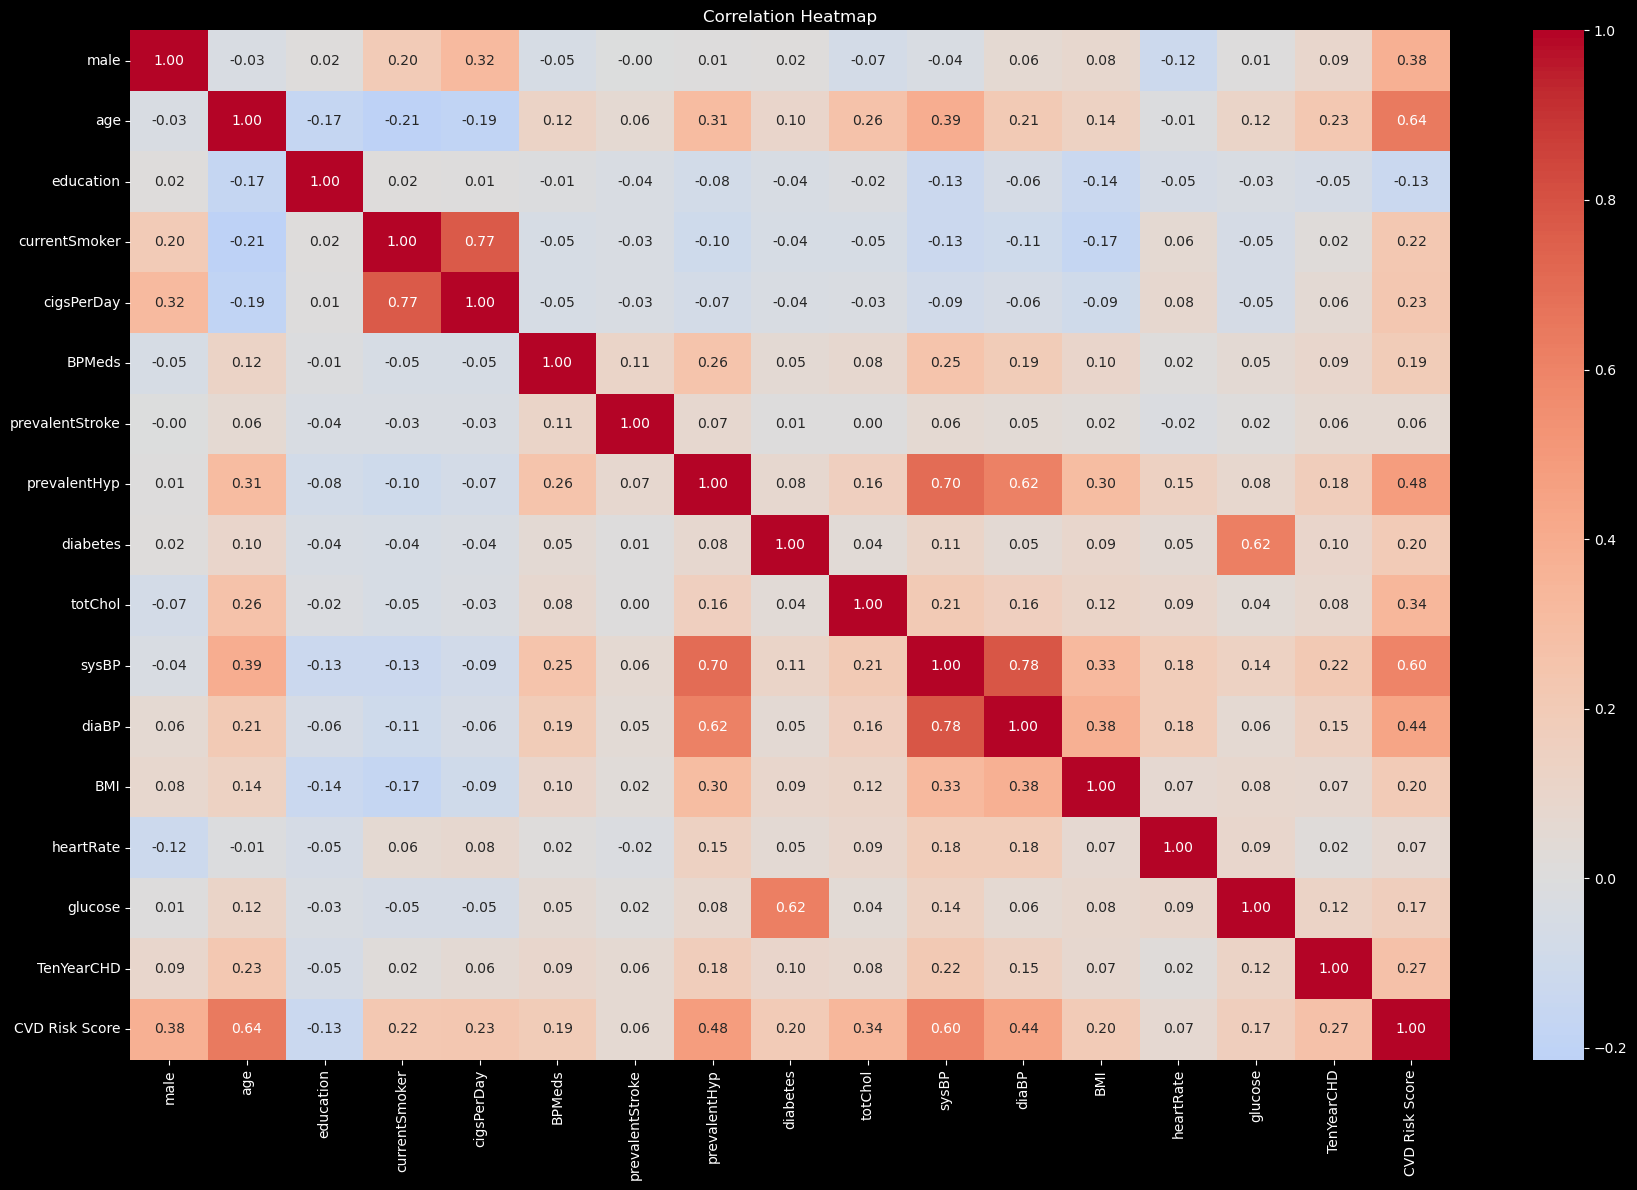

In [33]:
plt.figure(figsize=(18, 12))
correlation_matrix = df_continuous.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f',annot_kws={'size': 10})
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

## Convert bolean features to 0 and 1

In [34]:
df = df.map(lambda x:1 if x is True else 0 if x is False else x)
df['CVD Risk Level'] = df['CVD Risk Level'].map({v: i+1 for i, v in enumerate(order)})

##  🔨💡 Feature Engineering & dropping

In [35]:
df_feature_engineered = df.copy()


### 📐👷 hand crafted features

In [36]:
df_feature_engineered.columns


Index(['male', 'age', 'education', 'currentSmoker', 'cigsPerDay', 'BPMeds',
       'prevalentStroke', 'prevalentHyp', 'diabetes', 'totChol', 'sysBP',
       'diaBP', 'BMI', 'heartRate', 'glucose', 'TenYearCHD', 'CVD Risk Score',
       'CVD Risk Level'],
      dtype='object')

In [37]:
df_feature_engineered['pulse_pressure'] = df['sysBP'] - df['diaBP']

### 🗑 drop redundant or useless noisey features   

In [38]:
df_feature_engineered.drop('CVD Risk Level', axis=1, inplace= True)
#df_feature_engineered.drop('age', axis=1, inplace= True)
#df_feature_engineered.drop('male', axis=1, inplace= True)
df_feature_engineered.drop('education', axis=1, inplace= True)
df_feature_engineered.drop('sysBP', axis=1, inplace= True)
df_feature_engineered.drop('diaBP', axis=1, inplace= True)
df_feature_engineered.drop('totChol', axis=1, inplace= True)
df_feature_engineered.drop('BMI', axis=1, inplace= True)
#df_feature_engineered.drop('BPMeds', axis=1, inplace= True)
#df_feature_engineered.drop('diabetes', axis=1, inplace= True)
#df_feature_engineered.drop('currentSmoker', axis=1, inplace= True)
df_feature_engineered.drop('cigsPerDay', axis=1, inplace= True)
df_feature_engineered.drop('heartRate', axis=1, inplace= True)
df_feature_engineered.drop('glucose', axis=1, inplace= True)
df_feature_engineered.drop('prevalentStroke', axis=1, inplace= True)
#df_feature_engineered.drop('CVD Risk Score', axis=1, inplace= True)


In [39]:
df_feature_engineered.to_csv('CVD_feature_engineered_v3.csv',index=0)
df_feature_engineered

,male,age,currentSmoker,BPMeds,prevalentHyp,diabetes,TenYearCHD,CVD Risk Score,pulse_pressure
0,1,39,0,0.0,0,0,0,1.9,36.0
1,0,46,0,0.0,0,0,0,5.3,40.0
2,1,48,1,0.0,0,0,0,18.4,47.5
3,0,61,1,0.0,1,0,1,24.8,55.0
4,0,46,1,0.0,0,0,0,11.7,46.0
...,...,...,...,...,...,...,...,...,...
4235,0,48,1,0.0,0,0,0,10.0,59.0
4236,0,44,1,0.0,0,0,0,6.3,39.5
4237,0,52,0,0.0,0,0,0,8.6,50.5
4238,1,40,0,0.0,1,0,0,6.7,43.0


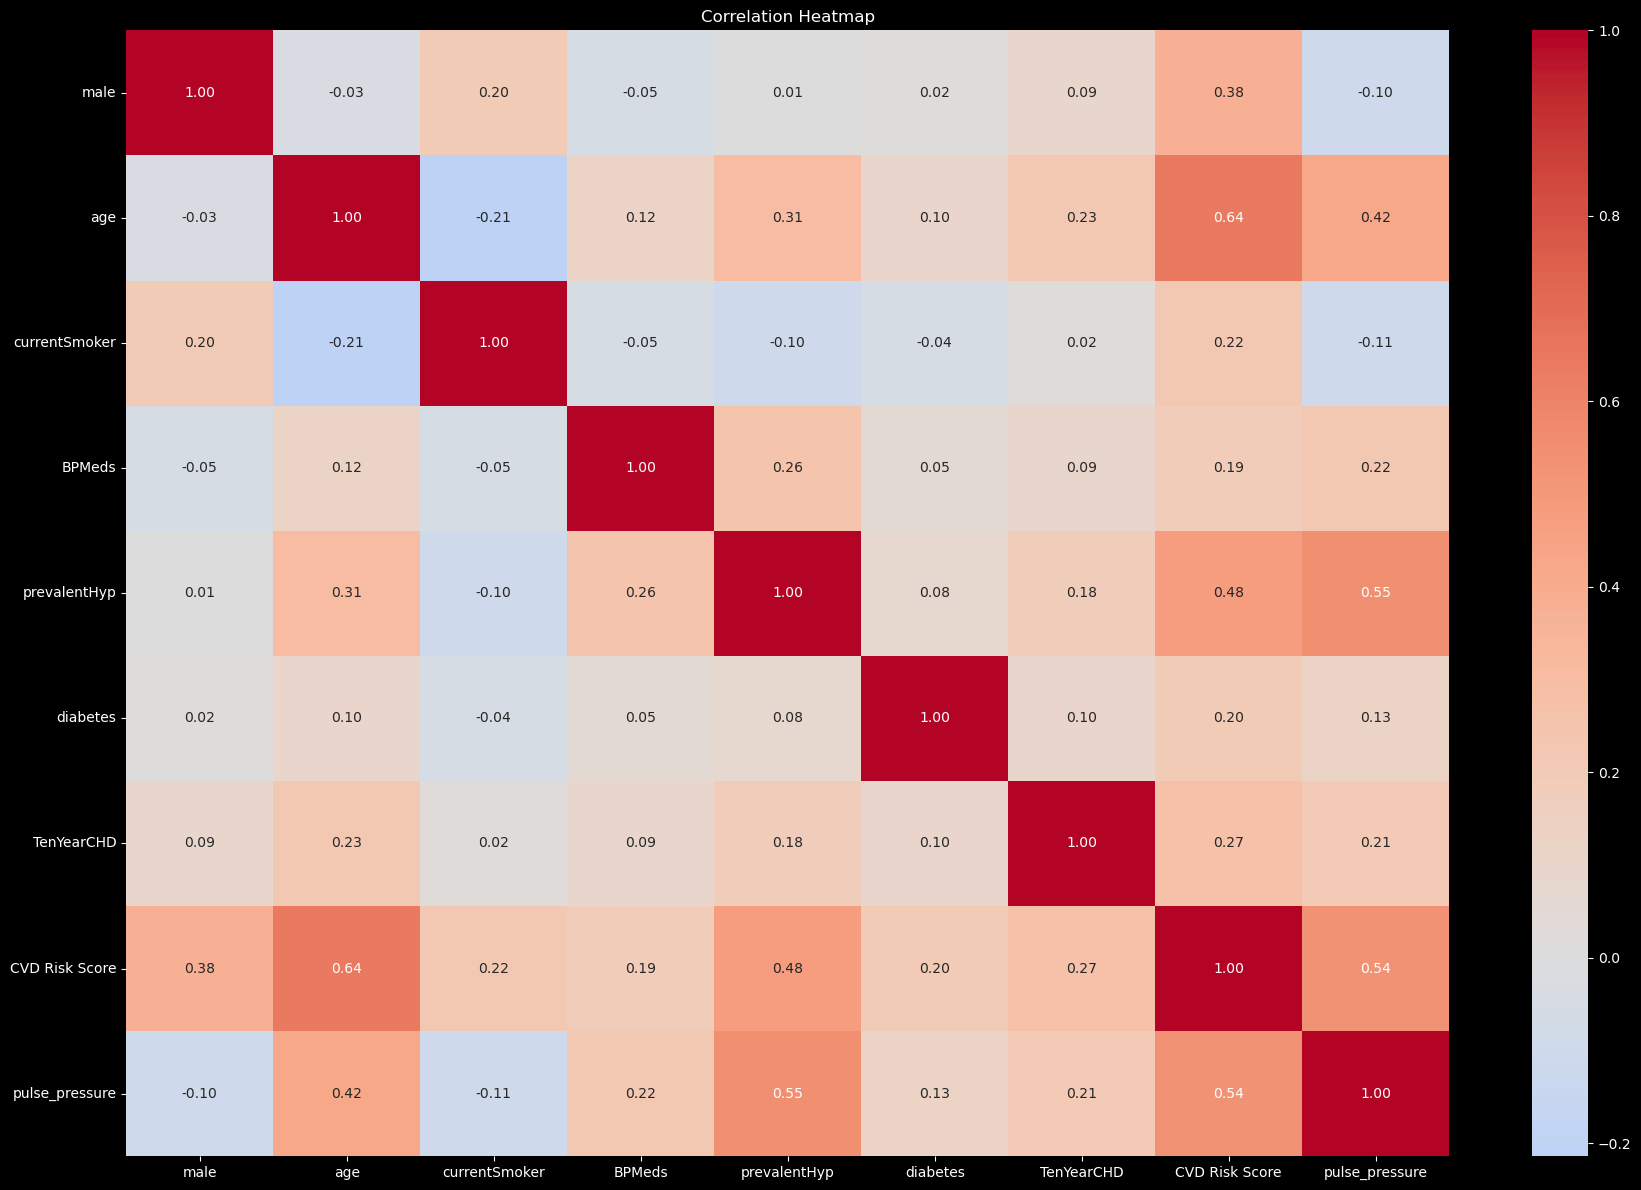

In [40]:
plt.figure(figsize=(18, 12))
correlation_matrix = df_feature_engineered.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f',annot_kws={'size': 10})
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

In [41]:
df_feature_engineered.columns

Index(['male', 'age', 'currentSmoker', 'BPMeds', 'prevalentHyp', 'diabetes',
       'TenYearCHD', 'CVD Risk Score', 'pulse_pressure'],
      dtype='object')

# Model

In [42]:
z = df_feature_engineered[['TenYearCHD','CVD Risk Score']] # to test the main score and compare it to the model
X = df_feature_engineered.drop(['TenYearCHD','CVD Risk Score'], axis=1)
y = df_feature_engineered['TenYearCHD']


In [43]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=1, stratify=y
)

In [44]:
z_train, z_test = train_test_split(
    z, test_size=0.2, random_state=1, stratify=y
)
baseline_auc = roc_auc_score(z_test['TenYearCHD'], z_test['CVD Risk Score'])

print(f"Baseline AUC-ROC (Doctor's Score): {baseline_auc:.4f}")

Baseline AUC-ROC (Doctor's Score): 0.7100


In [45]:
weights = compute_sample_weight(class_weight={0: 1, 1: 1}, y=y_train)
base_pipeline = ImbPipeline([
    ('scaler', StandardScaler()),
    ('smote', ADASYN(sampling_strategy=0.5, random_state=1,n_neighbors=2)),
    ('clean', TomekLinks()),
    ('model', SVC(C=0.01, kernel='linear', class_weight='balanced', probability=True, random_state=1))
])



calibrated_model = CalibratedClassifierCV(
    estimator=base_pipeline,
    method='sigmoid', 
    cv= 5 
)
calibrated_model.fit(X_train, y_train, sample_weight=weights)


e:\Coding\ANACONDA\Lib\site-packages\sklearn\calibration.py:378: UserWarning: Since Pipeline does not appear to accept sample_weight, sample weights will only be used for the calibration itself. This can be caused by a limitation of the current scikit-learn API. See the following issue for more details: https://github.com/scikit-learn/scikit-learn/issues/21134. Be warned that the result of the calibration is likely to be incorrect.
  warnings.warn(


CalibratedClassifierCV(cv=5,
                       estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                                 ('smote',
                                                  ADASYN(n_neighbors=2,
                                                         random_state=1,
                                                         sampling_strategy=0.5)),
                                                 ('clean', TomekLinks()),
                                                 ('model',
                                                  SVC(C=0.01,
                                                      class_weight='balanced',
                                                      kernel='linear',
                                                      probability=True,
                                                      random_state=1))]))

Final Model ROC-AUC Score: 0.7416


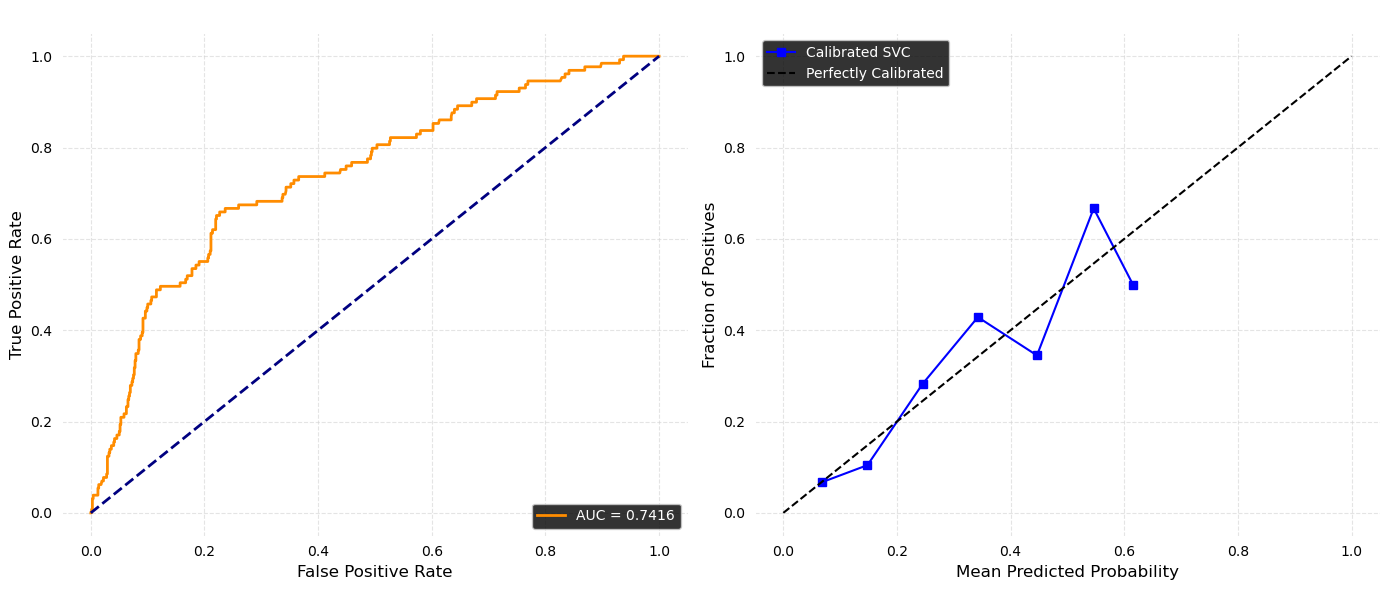

In [46]:
# 1. Get Probabilities
y_probs = calibrated_model.predict_proba(X_test)[:, 1]
roc_auc = roc_auc_score(y_test, y_probs)

print(f"Final Model ROC-AUC Score: {roc_auc:.4f}")

# 2. Plotting Results
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), facecolor='white')

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_probs)
ax1.set_facecolor('white')
ax1.plot(fpr, tpr, color='darkorange', lw=2, label=f"AUC = {roc_auc:.4f}")
ax1.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')

# Labels and visible axis numbers
ax1.set_xlabel('False Positive Rate', fontsize=12, color='black')
ax1.set_ylabel('True Positive Rate', fontsize=12, color='black')
ax1.set_title('ROC Curve', fontsize=14, fontweight='bold')
ax1.tick_params(axis='both', which='major', labelsize=10, labelcolor='black')

ax1.legend(loc="lower right")
ax1.grid(True, linestyle='--', alpha=0.6, color='lightgray')

# Calibration Curve
prob_true, prob_pred = calibration_curve(y_test, y_probs, n_bins=10)
ax2.set_facecolor('white')
ax2.plot(prob_pred, prob_true, marker='s', label='Calibrated SVC', color='blue')
ax2.plot([0, 1], [0, 1], 'k--', label='Perfectly Calibrated')

# Labels and visible axis numbers
ax2.set_xlabel('Mean Predicted Probability', fontsize=12, color='black')
ax2.set_ylabel('Fraction of Positives', fontsize=12, color='black')
ax2.set_title('Calibration Curve', fontsize=14, fontweight='bold')
ax2.tick_params(axis='both', which='major', labelsize=10, labelcolor='black')

ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.6, color='lightgray')

plt.tight_layout()
plt.show()